In [ ]:
!pip install imbalanced-learn openpyxl --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Preprocessing

Tahap **Data Cleansing** dan **Data Transformation** kini berada di file terpisah `preprocessing.py`. Sel di bawah ini hanya meng-import dan menjalankan fungsi `run_preprocessing()` dari file tersebut.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE
try:
    from google.colab import files
except ImportError:
    files = None
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# Tahap preprocessing (data cleansing + data transformation) dipisah
# ke file preprocessing.py agar notebook ini fokus pada pemodelan.
from preprocessing import bandingkan, run_preprocessing

hasil_preprocessing = run_preprocessing('dataset.xlsx', verbose=True)

df             = hasil_preprocessing['df']
X              = hasil_preprocessing['X']
X_raw          = hasil_preprocessing['X_raw']
X_scaled       = hasil_preprocessing['X_scaled']
scaler         = hasil_preprocessing['scaler']
le_gender      = hasil_preprocessing['le_gender']
le_jurusan     = hasil_preprocessing['le_jurusan']
le_kabupaten   = hasil_preprocessing['le_kabupaten']
media_cols     = hasil_preprocessing['media_cols']
FEATURE_COLS   = hasil_preprocessing['FEATURE_COLS']
feat_labels    = hasil_preprocessing['feat_labels']
feat_labels_en = hasil_preprocessing['feat_labels_en']
TARGET_COLS    = hasil_preprocessing['TARGET_COLS']
DIM_EN         = hasil_preprocessing['DIM_EN']

print("✅ Preprocessing (preprocessing.py) berhasil dijalankan & variabel siap dipakai.")


In [ ]:
print("=" * 65)
print("  SPLIT DATA 80:20")
print("=" * 65)

split_dict = {}
idx_all = df.index.values
baris_split = []

for dimensi_nama, target_col in TARGET_COLS.items():
    le_t = LabelEncoder()
    y    = le_t.fit_transform(df[target_col])

    idx_train, idx_test, X_train, X_test, y_train, y_test = train_test_split(
        idx_all, X_scaled, y,
        test_size=0.2, random_state=42, stratify=y
    )
    split_dict[dimensi_nama] = {
        'X_train'    : X_train, 'X_test'     : X_test,
        'y_train'    : y_train, 'y_test'      : y_test,
        'idx_train'  : idx_train, 'idx_test'  : idx_test,
        'le_target'  : le_t,
        'label_names': list(le_t.classes_),
    }
    kelas   = list(le_t.classes_)
    dist_tr = dict(zip(kelas, np.bincount(y_train)))
    dist_te = dict(zip(kelas, np.bincount(y_test)))
    for k in kelas:
        baris_split.append({
            'dimensi'         : dimensi_nama,
            'kelas'           : k,
            'data_latih_80persen': int(dist_tr[k]),
            'data_uji_20persen'  : int(dist_te[k]),
        })

# Hasil pembagian data per dimensi (DataFrame)
print(f"\nHasil pembagian data per dimensi "
      f"(latih = {len(split_dict[dimensi_nama]['X_train'])}, "
      f"uji = {len(split_dict[dimensi_nama]['X_test'])}):")
tabel_split = pd.DataFrame(baris_split)
display(tabel_split)

print("\n✅ Split data selesai.")


  SPLIT DATA 80:20



Hasil pembagian data per dimensi (latih = 168, uji = 42):


,dimensi,kelas,data_latih_80persen,data_uji_20persen
0,Memproses (Active vs Reflective),Active,124,31
1,Memproses (Active vs Reflective),Reflective,44,11
2,Menerima (Sensing vs Intuitive),Intuitive,40,10
3,Menerima (Sensing vs Intuitive),Sensing,128,32
4,Menyerap (Visual vs Verbal),Verbal,58,14
5,Menyerap (Visual vs Verbal),Visual,110,28
6,Memahami (Sequential vs Global),Global,30,8
7,Memahami (Sequential vs Global),Sequential,138,34



✅ Split data selesai.



  SMOTE (HANYA PADA DATA LATIH)

Distribusi kelas data latih sebelum dan sesudah SMOTE:


,dimensi,kelas,sebelum_smote,sesudah_smote,total_sebelum,total_sesudah
0,Memproses (Active vs Reflective),Active,124,124,168,248
1,Memproses (Active vs Reflective),Reflective,44,124,168,248
2,Menerima (Sensing vs Intuitive),Intuitive,40,128,168,256
3,Menerima (Sensing vs Intuitive),Sensing,128,128,168,256
4,Menyerap (Visual vs Verbal),Verbal,58,110,168,220
5,Menyerap (Visual vs Verbal),Visual,110,110,168,220
6,Memahami (Sequential vs Global),Global,30,138,168,276
7,Memahami (Sequential vs Global),Sequential,138,138,168,276


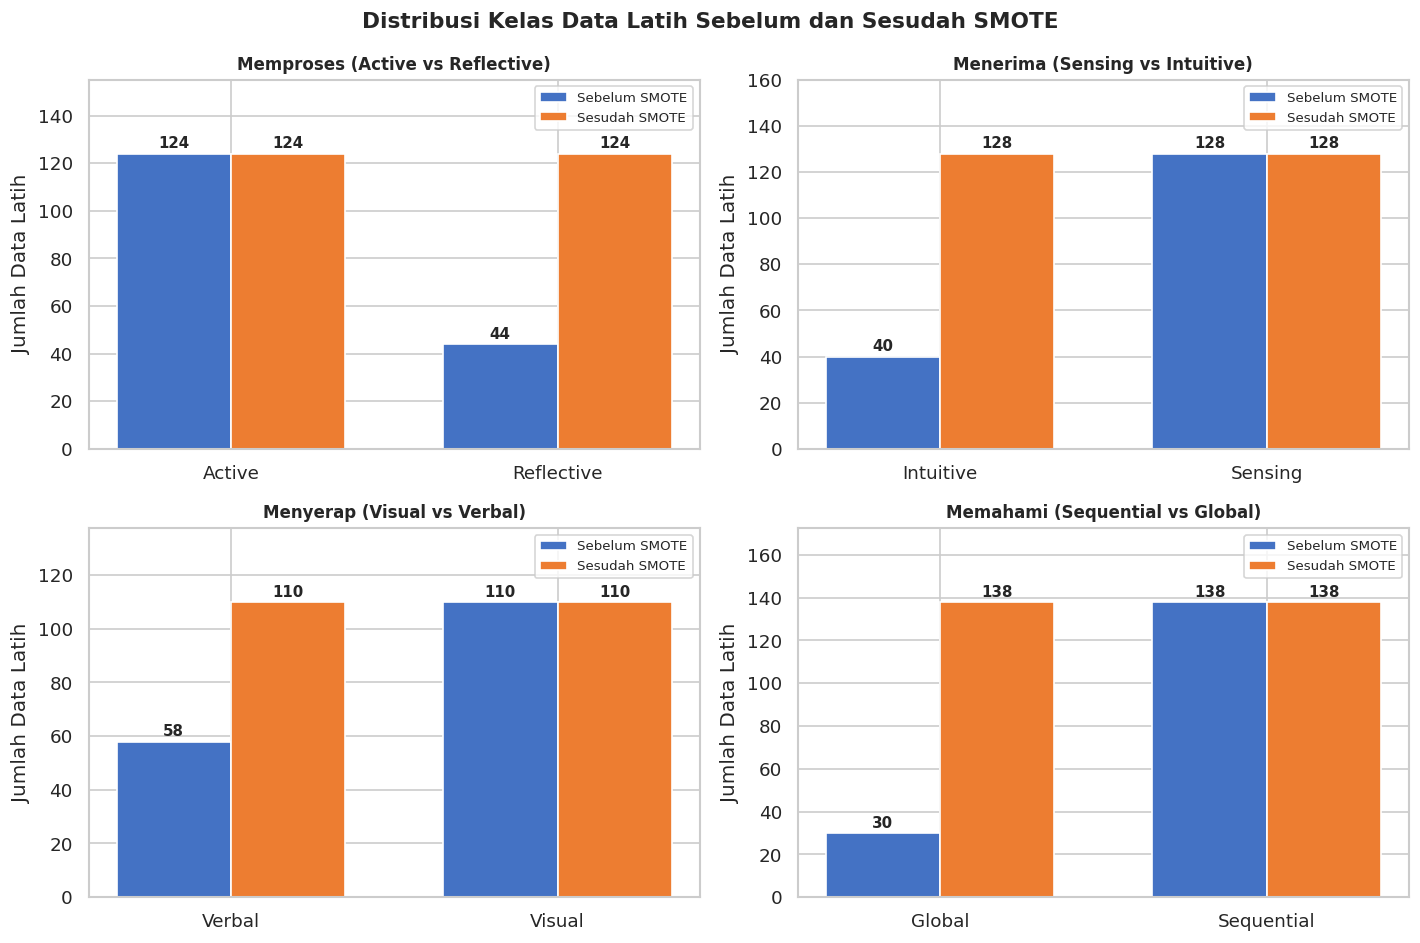


✅ SMOTE selesai.


In [ ]:
print("=" * 65)
print("  SMOTE (HANYA PADA DATA LATIH)")
print("=" * 65)

smote_dict  = {}
baris_smote = []

for dimensi_nama in TARGET_COLS:
    info        = split_dict[dimensi_nama]
    X_train     = info['X_train']
    y_train     = info['y_train']
    label_names = info['label_names']

    try:
        k  = max(1, min(4, int(np.min(np.bincount(y_train))) - 1))
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_sm, y_sm = sm.fit_resample(X_train, y_train)
    except Exception as e:
        print(f"  SMOTE dilewati: {e}")
        X_sm, y_sm = X_train, y_train

    smote_dict[dimensi_nama] = {'X_train_sm': X_sm, 'y_train_sm': y_sm}

    sebelum = dict(zip(label_names, np.bincount(y_train)))
    sesudah = dict(zip(label_names, np.bincount(y_sm)))
    for kls in label_names:
        baris_smote.append({
            'dimensi'       : dimensi_nama,
            'kelas'         : kls,
            'sebelum_smote' : int(sebelum[kls]),
            'sesudah_smote' : int(sesudah[kls]),
            'total_sebelum' : len(y_train),
            'total_sesudah' : len(y_sm),
        })

# Distribusi kelas sebelum & sesudah SMOTE (DataFrame)
print("\nDistribusi kelas data latih sebelum dan sesudah SMOTE:")
tabel_smote = pd.DataFrame(baris_smote)
display(tabel_smote)


# Grafik distribusi kelas data latih sebelum vs sesudah SMOTE (4 dimensi)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, dimensi_nama in zip(axes.flat, TARGET_COLS):
    label_names = split_dict[dimensi_nama]['label_names']
    seb = np.bincount(split_dict[dimensi_nama]['y_train'])
    ses = np.bincount(smote_dict[dimensi_nama]['y_train_sm'])
    x   = np.arange(len(label_names)); lebar = 0.35
    b1  = ax.bar(x - lebar/2, seb, lebar, label='Sebelum SMOTE', color='#4472C4')
    b2  = ax.bar(x + lebar/2, ses, lebar, label='Sesudah SMOTE', color='#ED7D31')
    for bars in (b1, b2):
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{int(bar.get_height())}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(label_names)
    ax.set_ylabel('Jumlah Data Latih')
    ax.set_ylim(0, max(seb.max(), ses.max()) * 1.25)
    ax.set_title(dimensi_nama, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Distribusi Kelas Data Latih Sebelum dan Sesudah SMOTE',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('smote_distribusi.png', bbox_inches='tight')
plt.show()

print("\n✅ SMOTE selesai.")


In [ ]:
def plot_cm(cm, classes, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(DIM_EN.get(title, title), fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

def narasi_confusion_matrix(cm, label_names, nama_model, dimensi_nama):
    """Menjelaskan isi confusion matrix dalam bentuk paragraf naratif,
    kelas per kelas (berapa yang benar dan ke mana kesalahannya lari)."""
    total = cm.sum()
    print(f"\n  Rincian Confusion Matrix — {nama_model} ({dimensi_nama}):")
    print(f"  {'─'*60}")
    for i, kelas in enumerate(label_names):
        benar = cm[i, i]
        salah_ke = [f"{cm[i, j]} data sebagai {label_names[j]}"
                    for j in range(len(label_names)) if j != i and cm[i, j] > 0]
        teks_salah = " dan ".join(salah_ke) if salah_ke else "tidak ada"
        print(f"  Kelas {kelas:<12}: {benar} data berhasil diklasifikasikan dengan benar; "
              f"kesalahan terjadi pada {teks_salah}.")
    diag = np.trace(cm)
    print(f"  Total data uji     : {total}")
    print(f"  Prediksi benar     : {diag} ({diag/total*100:.2f}%)")
    print(f"  Prediksi salah     : {total-diag} ({(total-diag)/total*100:.2f}%)")

def formula_metrik(nama_model, y_true, y_pred, label_names):
    """Menampilkan perhitungan accuracy, precision, recall, dan f1-score
    sebagai formula eksplisit dengan angka aslinya (bukan hanya nilai akhir),
    mengikuti gaya penyajian pada Bab IV skripsi rujukan."""
    cm    = confusion_matrix(y_true, y_pred)
    benar = np.trace(cm)
    total = cm.sum()
    acc   = benar / total

    prec_pc = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_pc  = recall_score(y_true, y_pred,    average=None, zero_division=0)
    f1_pc   = f1_score(y_true, y_pred,        average=None, zero_division=0)
    n_kelas = len(label_names)

    prec_avg = prec_pc.mean()
    rec_avg  = rec_pc.mean()
    f1_avg   = f1_pc.mean()

    print(f"\n  Perhitungan Metrik Evaluasi — {nama_model}:")
    print(f"  {'─'*60}")
    print(f"  a. Accuracy")
    print(f"     Accuracy  = {benar}/{total} = {acc:.4f}")
    print(f"  b. Precision")
    print(f"     Precision = ({' + '.join(f'{p:.4f}' for p in prec_pc)}) / {n_kelas} = {prec_avg:.4f}")
    print(f"  c. Recall")
    print(f"     Recall    = ({' + '.join(f'{r:.4f}' for r in rec_pc)}) / {n_kelas} = {rec_avg:.4f}")
    print(f"  d. F1-score")
    print(f"     F1-score  = ({' + '.join(f'{f:.4f}' for f in f1_pc)}) / {n_kelas} = {f1_avg:.4f}")
    return acc, prec_avg, rec_avg, f1_avg

def tampilkan_kesalahan_prediksi(nama_model, dimensi_nama, idx_test, y_true,
                                  y_pred, label_names, df_ref, n_contoh=10):
    """Menampilkan contoh data uji yang diprediksi tidak sesuai dengan label
    aktual — setara dengan tabel 'Kesalahan Prediksi Label' pada Bab IV
    skripsi rujukan, namun memakai identitas responden sebagai pengganti teks."""
    label_asli = [label_names[v] for v in y_true]
    label_pred = [label_names[v] for v in y_pred]
    df_cek = pd.DataFrame({
        'responden'  : df_ref.loc[idx_test, 'nama'].values,
        'jurusan'    : df_ref.loc[idx_test, 'jurusan_std'].values,
        'label_asli' : label_asli,
        'label_pred' : label_pred,
    })
    df_salah = df_cek[df_cek['label_asli'] != df_cek['label_pred']].head(n_contoh)
    print(f"\n  Contoh Kesalahan Prediksi — {nama_model} ({dimensi_nama}):")
    print(f"  {'─'*70}")
    if len(df_salah) == 0:
        print("  Tidak ada kesalahan prediksi pada data uji.")
    else:
        print(df_salah.to_string(index=False))
    return df_salah

def plot_performa_persen(nama_model, dimensi_nama, acc, prec, rec, f1, fname):
    """Grafik batang performa model dalam bentuk persentase dengan label
    nilai di atas setiap batang — mengikuti format 'Grafik Performa Model'
    pada Bab IV skripsi rujukan."""
    metrik  = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    nilai   = [acc*100, prec*100, rec*100, f1*100]
    warna   = ['#4472C4', '#ED7D31', '#70AD47', '#C00000']
    fig, ax = plt.subplots(figsize=(6, 4.5))
    bars = ax.bar(metrik, nilai, color=warna, alpha=0.9)
    for bar, v in zip(bars, nilai):
        ax.text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Persentase (%)')
    ax.set_title(f"Grafik Performa Model {nama_model}\n{dimensi_nama}",
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

def evaluasi(nama_model, y_true, y_pred, label_names):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    print(f"\n  {'─'*55}")
    print(f"  {nama_model}")
    print(f"  {'─'*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")
    return {'Model': nama_model, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

all_results    = []
trained_models = {}
print("✅ Fungsi evaluasi siap. Lanjut ke pelatihan model.")

✅ Fungsi evaluasi siap. Lanjut ke pelatihan model.


  KLASIFIKASI — RANDOM FOREST
  (200 pohon, class_weight='balanced')

▶ Dimensi: Memproses (Active vs Reflective)
  Data latih (setelah SMOTE) : 248
  Data uji (asli)            : 42



  ───────────────────────────────────────────────────────
  Random Forest — Memproses (Active vs Reflective)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.6667  (66.67%)
  Precision : 0.6465
  Recall    : 0.6667
  F1-Score  : 0.6552

              precision    recall  f1-score   support

      Active       0.76      0.81      0.78        31
  Reflective       0.33      0.27      0.30        11

    accuracy                           0.67        42
   macro avg       0.55      0.54      0.54        42
weighted avg       0.65      0.67      0.66        42


  Rincian Confusion Matrix — Random Forest (Memproses (Active vs Reflective)):
  ────────────────────────────────────────────────────────────
  Kelas Active      : 25 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 6 data sebagai Reflective.
  Kelas Reflective  : 3 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 8 data sebagai Active.
  Total data uji     : 42
  Pred

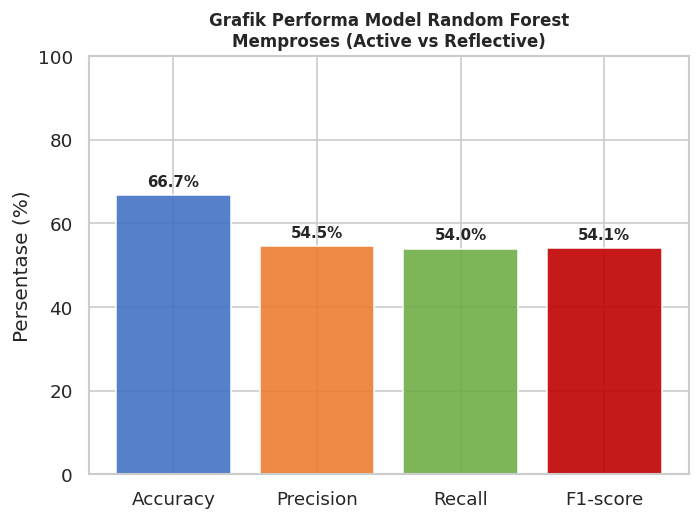

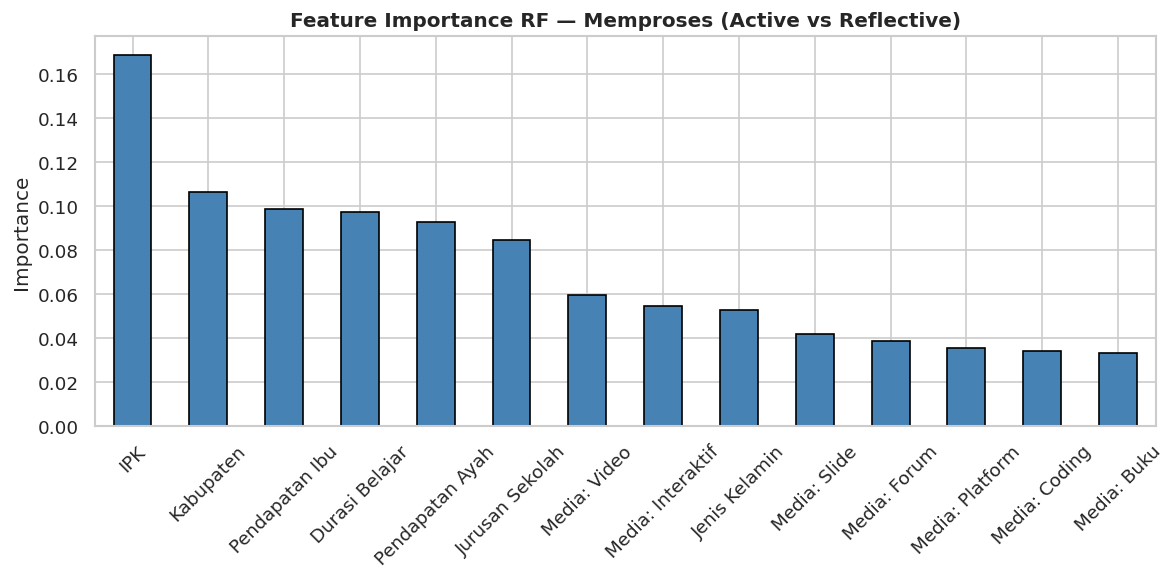


  Feature Importance RF — Memproses (Active vs Reflective):
  IPK                  0.1689 ██████
  Kabupaten            0.1064 ████
  Pendapatan Ibu       0.0988 ███
  Durasi Belajar       0.0974 ███
  Pendapatan Ayah      0.0930 ███
  Jurusan Sekolah      0.0845 ███
  Media: Video         0.0598 ██
  Media: Interaktif    0.0548 ██
  Jenis Kelamin        0.0530 ██
  Media: Slide         0.0419 █
  Media: Forum         0.0385 █
  Media: Platform      0.0354 █
  Media: Coding        0.0342 █
  Media: Buku          0.0335 █

▶ Dimensi: Menerima (Sensing vs Intuitive)
  Data latih (setelah SMOTE) : 256
  Data uji (asli)            : 42

  ───────────────────────────────────────────────────────
  Random Forest — Menerima (Sensing vs Intuitive)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.7381  (73.81%)
  Precision : 0.7292
  Recall    : 0.7381
  F1-Score  : 0.7332

              precision    recall  f1-score   support

   Intuitive       0.44      0.40      0.4

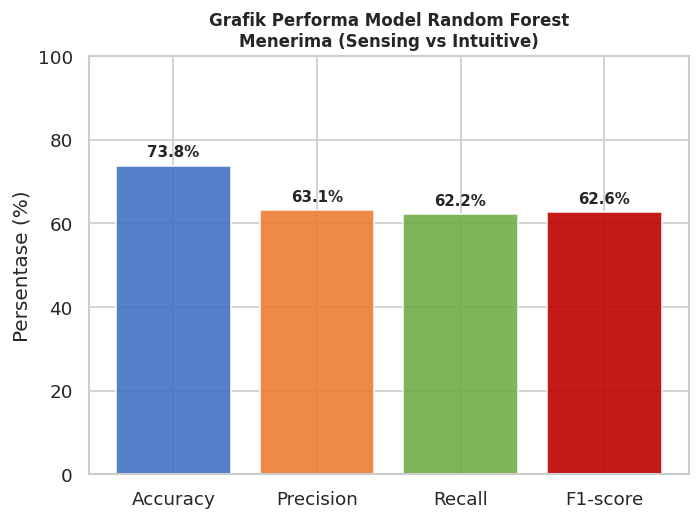

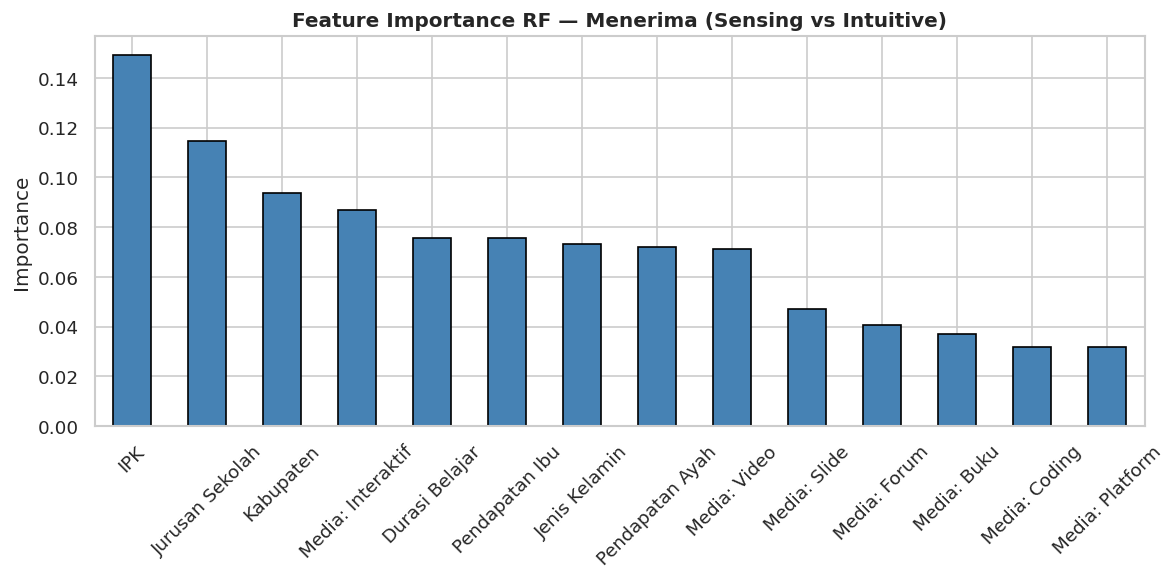


  Feature Importance RF — Menerima (Sensing vs Intuitive):
  IPK                  0.1492 █████
  Jurusan Sekolah      0.1145 ████
  Kabupaten            0.0938 ███
  Media: Interaktif    0.0870 ███
  Durasi Belajar       0.0755 ███
  Pendapatan Ibu       0.0755 ███
  Jenis Kelamin        0.0733 ██
  Pendapatan Ayah      0.0721 ██
  Media: Video         0.0712 ██
  Media: Slide         0.0471 █
  Media: Forum         0.0405 █
  Media: Buku          0.0371 █
  Media: Coding        0.0317 █
  Media: Platform      0.0316 █

▶ Dimensi: Menyerap (Visual vs Verbal)
  Data latih (setelah SMOTE) : 220
  Data uji (asli)            : 42

  ───────────────────────────────────────────────────────
  Random Forest — Menyerap (Visual vs Verbal)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.6429  (64.29%)
  Precision : 0.6246
  Recall    : 0.6429
  F1-Score  : 0.6305

              precision    recall  f1-score   support

      Verbal       0.45      0.36      0.40        1

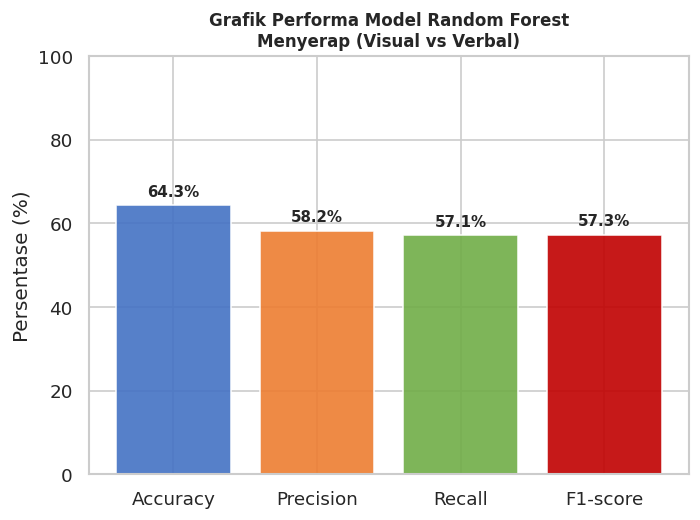

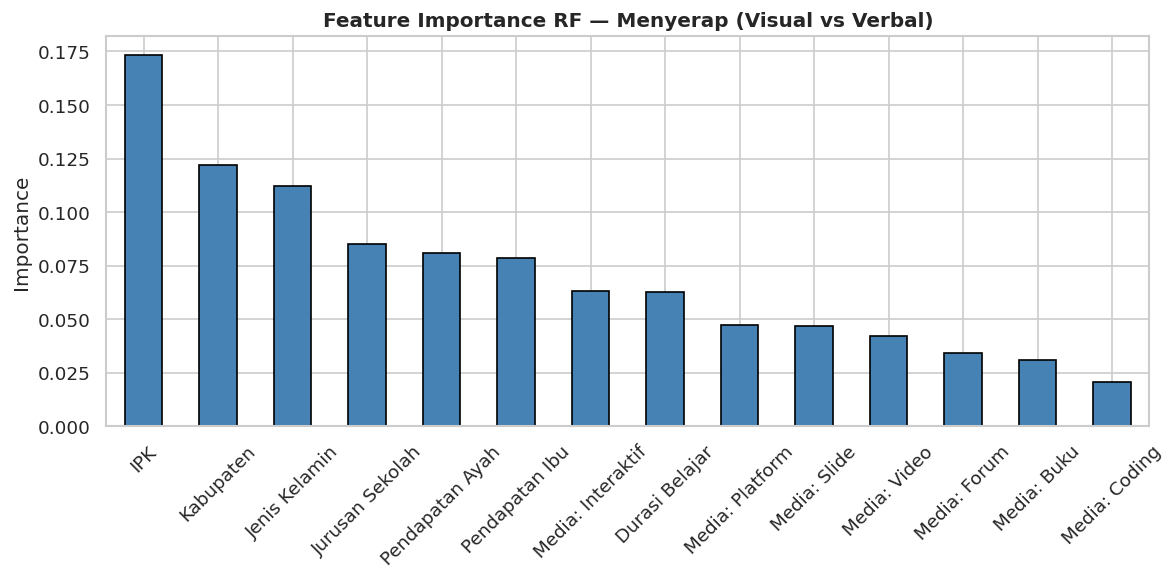


  Feature Importance RF — Menyerap (Visual vs Verbal):
  IPK                  0.1734 ██████
  Kabupaten            0.1220 ████
  Jenis Kelamin        0.1119 ████
  Jurusan Sekolah      0.0851 ███
  Pendapatan Ayah      0.0810 ███
  Pendapatan Ibu       0.0786 ███
  Media: Interaktif    0.0634 ██
  Durasi Belajar       0.0625 ██
  Media: Platform      0.0471 █
  Media: Slide         0.0469 █
  Media: Video         0.0422 █
  Media: Forum         0.0341 █
  Media: Buku          0.0310 █
  Media: Coding        0.0208 

▶ Dimensi: Memahami (Sequential vs Global)
  Data latih (setelah SMOTE) : 276
  Data uji (asli)            : 42

  ───────────────────────────────────────────────────────
  Random Forest — Memahami (Sequential vs Global)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.7857  (78.57%)
  Precision : 0.7544
  Recall    : 0.7857
  F1-Score  : 0.7655



              precision    recall  f1-score   support

      Global       0.40      0.25      0.31         8
  Sequential       0.84      0.91      0.87        34

    accuracy                           0.79        42
   macro avg       0.62      0.58      0.59        42
weighted avg       0.75      0.79      0.77        42


  Rincian Confusion Matrix — Random Forest (Memahami (Sequential vs Global)):
  ────────────────────────────────────────────────────────────
  Kelas Global      : 2 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 6 data sebagai Sequential.
  Kelas Sequential  : 31 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 3 data sebagai Global.
  Total data uji     : 42
  Prediksi benar     : 33 (78.57%)
  Prediksi salah     : 9 (21.43%)

  Perhitungan Metrik Evaluasi — Random Forest:
  ────────────────────────────────────────────────────────────
  a. Accuracy
     Accuracy  = 33/42 = 0.7857
  b. Precision
     Precision = (0.4000 + 0

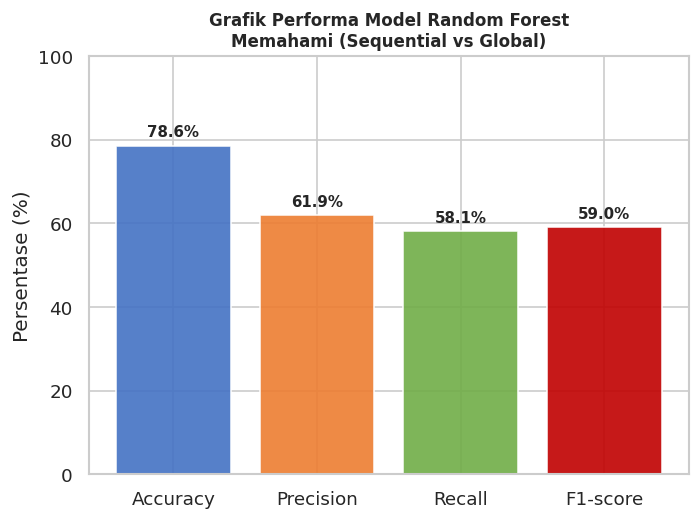

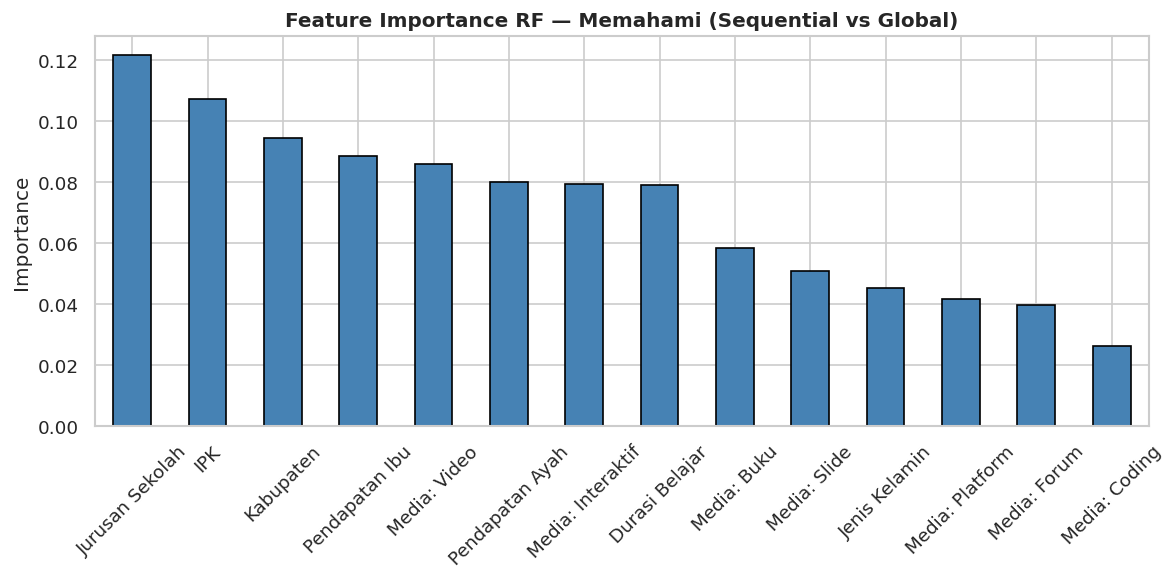


  Feature Importance RF — Memahami (Sequential vs Global):
  Jurusan Sekolah      0.1218 ████
  IPK                  0.1075 ████
  Kabupaten            0.0946 ███
  Pendapatan Ibu       0.0886 ███
  Media: Video         0.0861 ███
  Pendapatan Ayah      0.0800 ███
  Media: Interaktif    0.0794 ███
  Durasi Belajar       0.0791 ███
  Media: Buku          0.0584 ██
  Media: Slide         0.0509 ██
  Jenis Kelamin        0.0454 █
  Media: Platform      0.0418 █
  Media: Forum         0.0399 █
  Media: Coding        0.0264 █


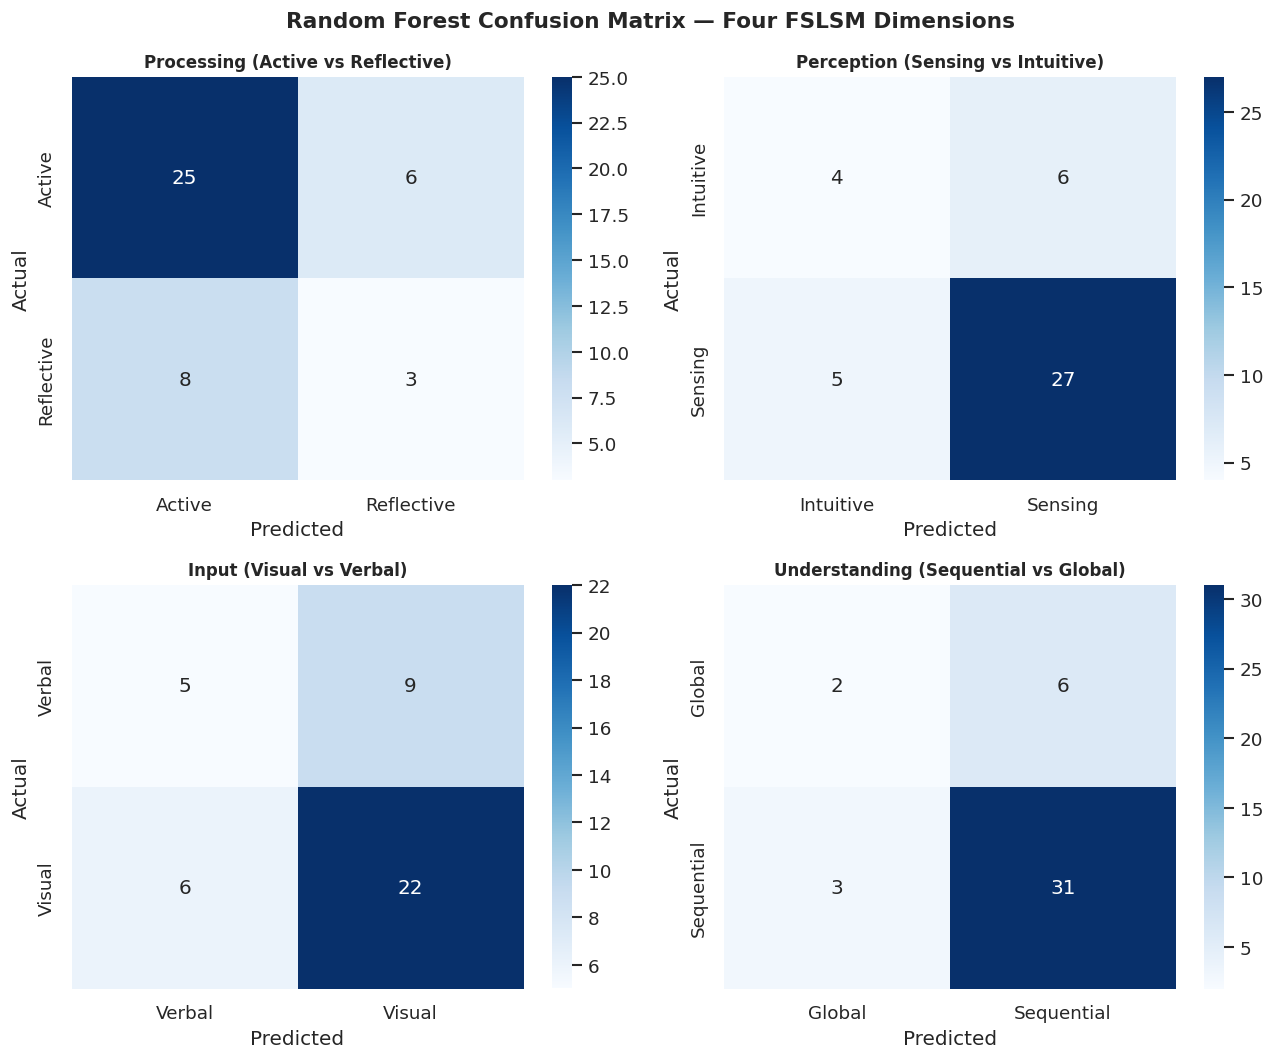


✅ Random Forest selesai untuk semua dimensi.


In [ ]:
print("=" * 65)
print("  KLASIFIKASI — RANDOM FOREST")
print("  (200 pohon, class_weight='balanced')")
print("=" * 65)

cm_semua_rf = {}

for dimensi_nama, target_col in TARGET_COLS.items():
    print(f"\n▶ Dimensi: {dimensi_nama}")
    X_sm        = smote_dict[dimensi_nama]['X_train_sm']
    y_sm        = smote_dict[dimensi_nama]['y_train_sm']
    X_test      = split_dict[dimensi_nama]['X_test']
    y_test      = split_dict[dimensi_nama]['y_test']
    label_names = split_dict[dimensi_nama]['label_names']

    print(f"  Data latih (setelah SMOTE) : {len(X_sm)}")
    print(f"  Data uji (asli)            : {len(X_test)}")

    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    rf.fit(X_sm, y_sm)
    y_pred = rf.predict(X_test)

    res = evaluasi(f"Random Forest — {dimensi_nama}", y_test, y_pred, label_names)
    res['Dimensi'] = dimensi_nama
    all_results.append(res)

    if dimensi_nama not in trained_models:
        trained_models[dimensi_nama] = {}
    trained_models[dimensi_nama].update({
        'rf': rf, 'y_pred_rf': y_pred, 'label_names': label_names
    })

    # Confusion Matrix (dikumpulkan; digambar gabungan setelah semua dimensi)
    cm_rf = confusion_matrix(y_test, y_pred)
    cm_semua_rf[dimensi_nama] = (cm_rf, label_names)

    # Rincian naratif confusion matrix + formula metrik eksplisit
    narasi_confusion_matrix(cm_rf, label_names, "Random Forest", dimensi_nama)
    acc_f, prec_f, rec_f, f1_f = formula_metrik("Random Forest", y_test, y_pred, label_names)

    # Contoh kesalahan prediksi pada data uji
    idx_test = split_dict[dimensi_nama]['idx_test']
    tampilkan_kesalahan_prediksi("Random Forest", dimensi_nama, idx_test,
                                 y_test, y_pred, label_names, df)

    # Grafik performa (persentase) khusus dimensi ini
    plot_performa_persen("Random Forest", dimensi_nama, acc_f, prec_f, rec_f, f1_f,
                          f'performa_rf_{target_col}.png')

    # Feature Importance
    fi = pd.Series(rf.feature_importances_, index=feat_labels).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    fi.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f"Feature Importance RF — {dimensi_nama}", fontweight='bold')
    ax.set_ylabel("Importance")
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f'fi_rf_{target_col}.png', bbox_inches='tight')
    plt.show()
    print(f"\n  Feature Importance RF — {dimensi_nama}:")
    for fname, fval in fi.items():
        bar = '█' * int(fval * 40)
        print(f"  {fname:<20} {fval:.4f} {bar}")


# Confusion Matrix gabungan: satu gambar berisi empat dimensi FSLSM
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (dimensi_nama, (cm, label_names)) in zip(axes.flat, cm_semua_rf.items()):
    plot_cm(cm, label_names, dimensi_nama, ax)
fig.suptitle('Random Forest Confusion Matrix — Four FSLSM Dimensions',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_rf_semua_dimensi.png', bbox_inches='tight')
plt.show()

print("\n✅ Random Forest selesai untuk semua dimensi.")

  KLASIFIKASI — DECISION TREE (CART)
  (criterion='gini', max_depth=5, class_weight='balanced')

▶ Dimensi: Memproses (Active vs Reflective)

  ───────────────────────────────────────────────────────
  Decision Tree — Memproses (Active vs Reflective)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.5952  (59.52%)
  Precision : 0.6496
  Recall    : 0.5952
  F1-Score  : 0.6150

              precision    recall  f1-score   support

      Active       0.77      0.65      0.70        31
  Reflective       0.31      0.45      0.37        11

    accuracy                           0.60        42
   macro avg       0.54      0.55      0.54        42
weighted avg       0.65      0.60      0.61        42


  Rincian Confusion Matrix — Decision Tree (Memproses (Active vs Reflective)):
  ────────────────────────────────────────────────────────────
  Kelas Active      : 20 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 11 data sebagai Reflective.
  Kel

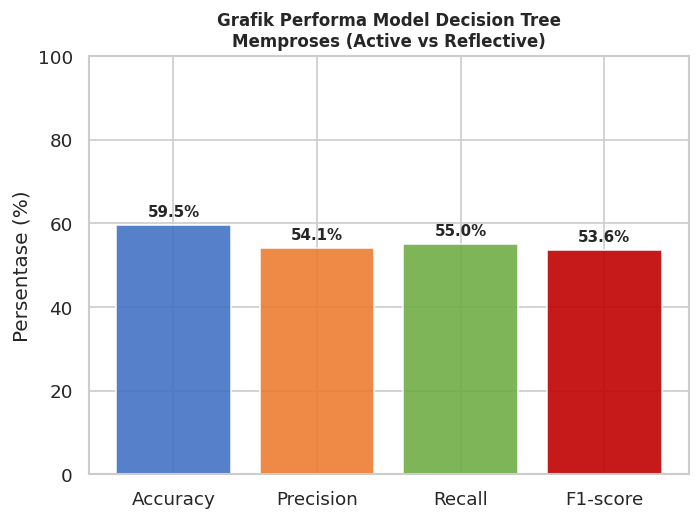

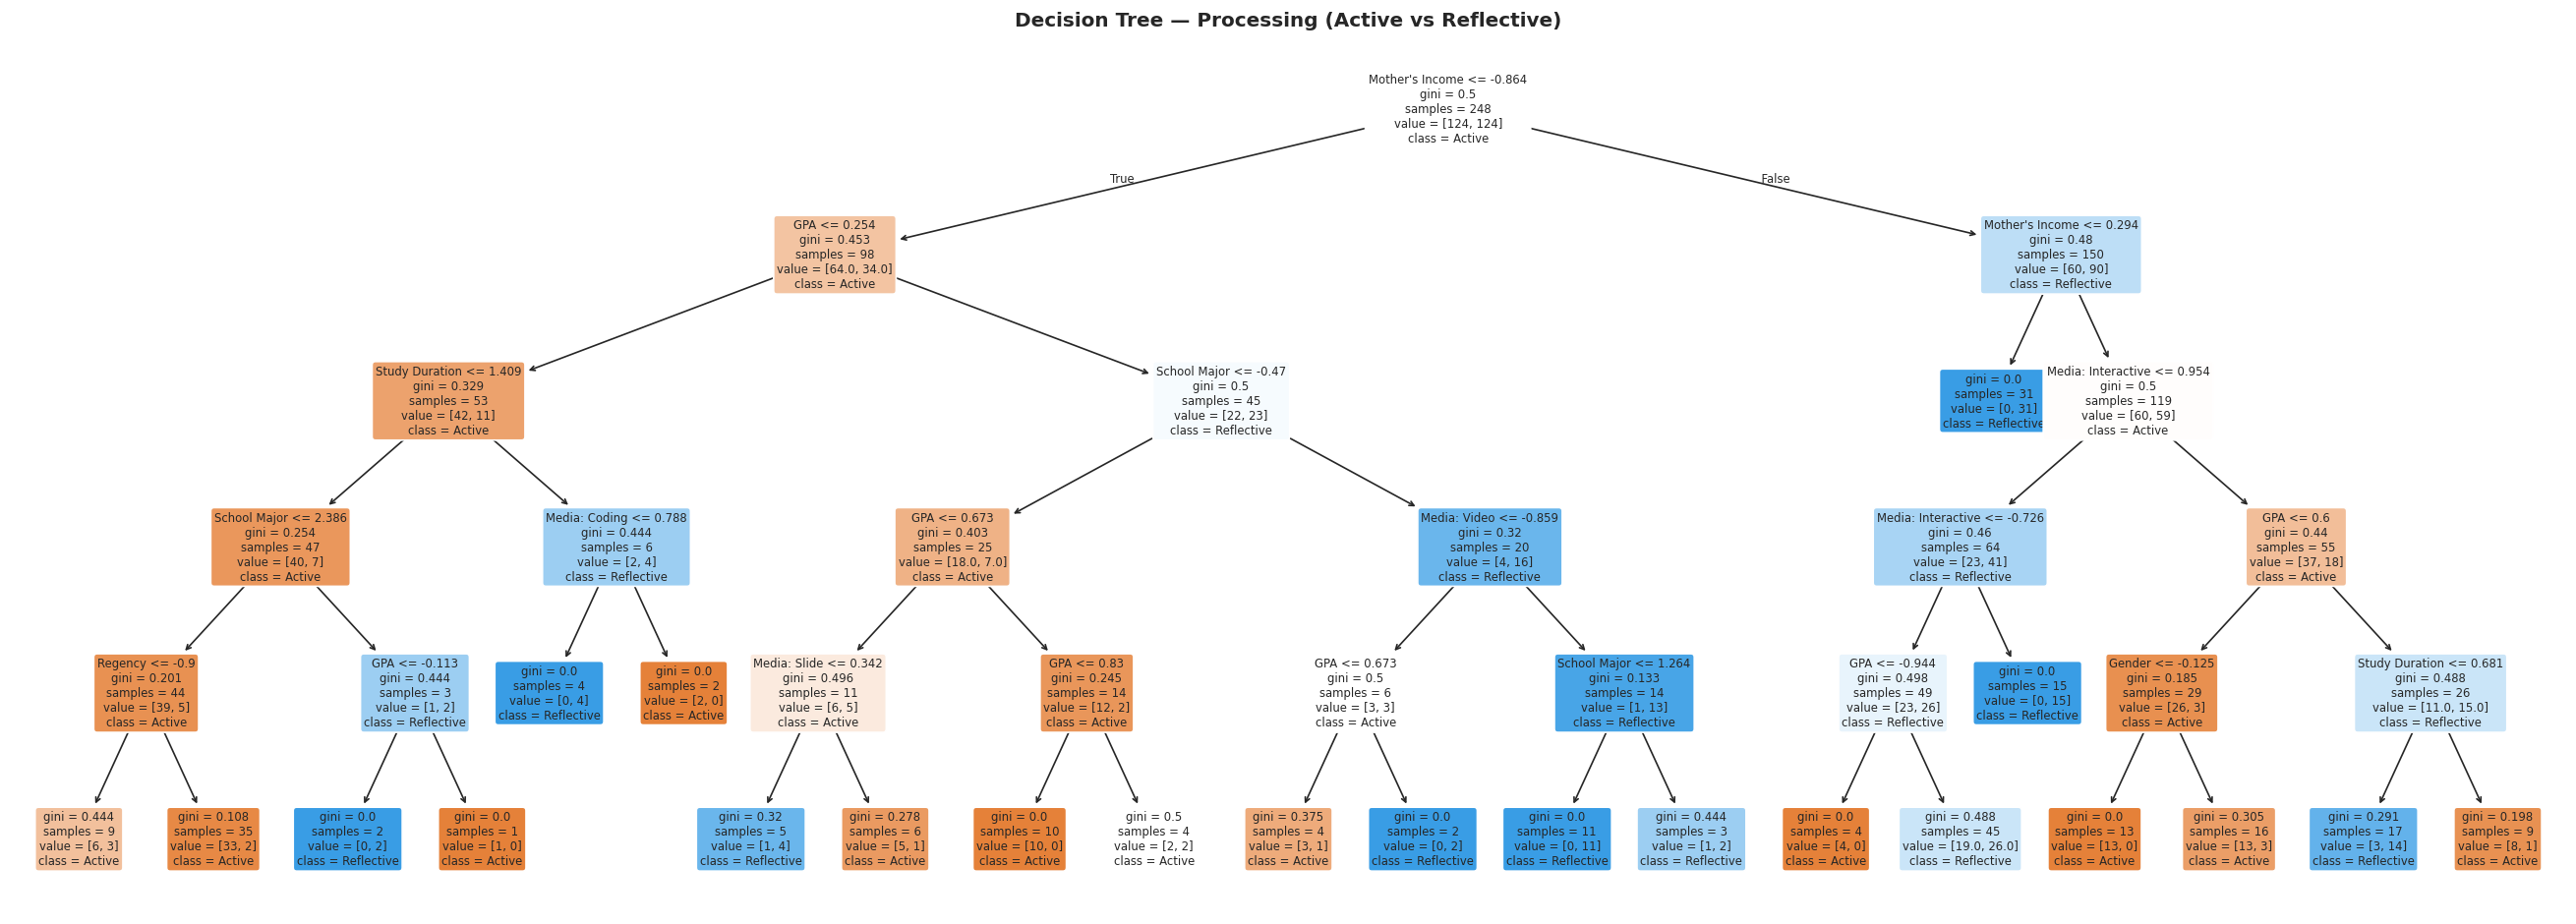


  Aturan Pohon (Decision Tree):
|--- Pendapatan Ibu <= -0.86
|   |--- IPK <= 0.25
|   |   |--- Durasi Belajar <= 1.41
|   |   |   |--- Jurusan Sekolah <= 2.39
|   |   |   |   |--- Kabupaten <= -0.90
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Kabupaten >  -0.90
|   |   |   |   |   |--- class: 0
|   |   |   |--- Jurusan Sekolah >  2.39
|   |   |   |   |--- IPK <= -0.11
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- IPK >  -0.11
|   |   |   |   |   |--- class: 0
|   |   |--- Durasi Belajar >  1.41
|   |   |   |--- Media: Coding <= 0.79
|   |   |   |   |--- class: 1
|   |   |   |--- Media: Coding >  0.79
|   |   |   |   |--- class: 0
|   |--- IPK >  0.25
|   |   |--- Jurusan Sekolah <= -0.47
|   |   |   |--- IPK <= 0.67
|   |   |   |   |--- Media: Slide <= 0.34
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Media: Slide >  0.34
|   |   |   |   |   |--- class: 0
|   |   |   |--- IPK >  0.67
|   |   |   |   |--- IPK <= 0.83
|   |   |   |   |   |--- class: 0
|   |

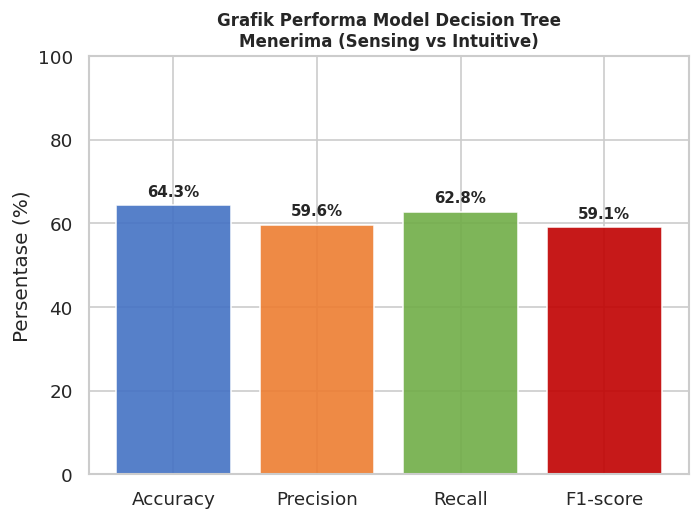

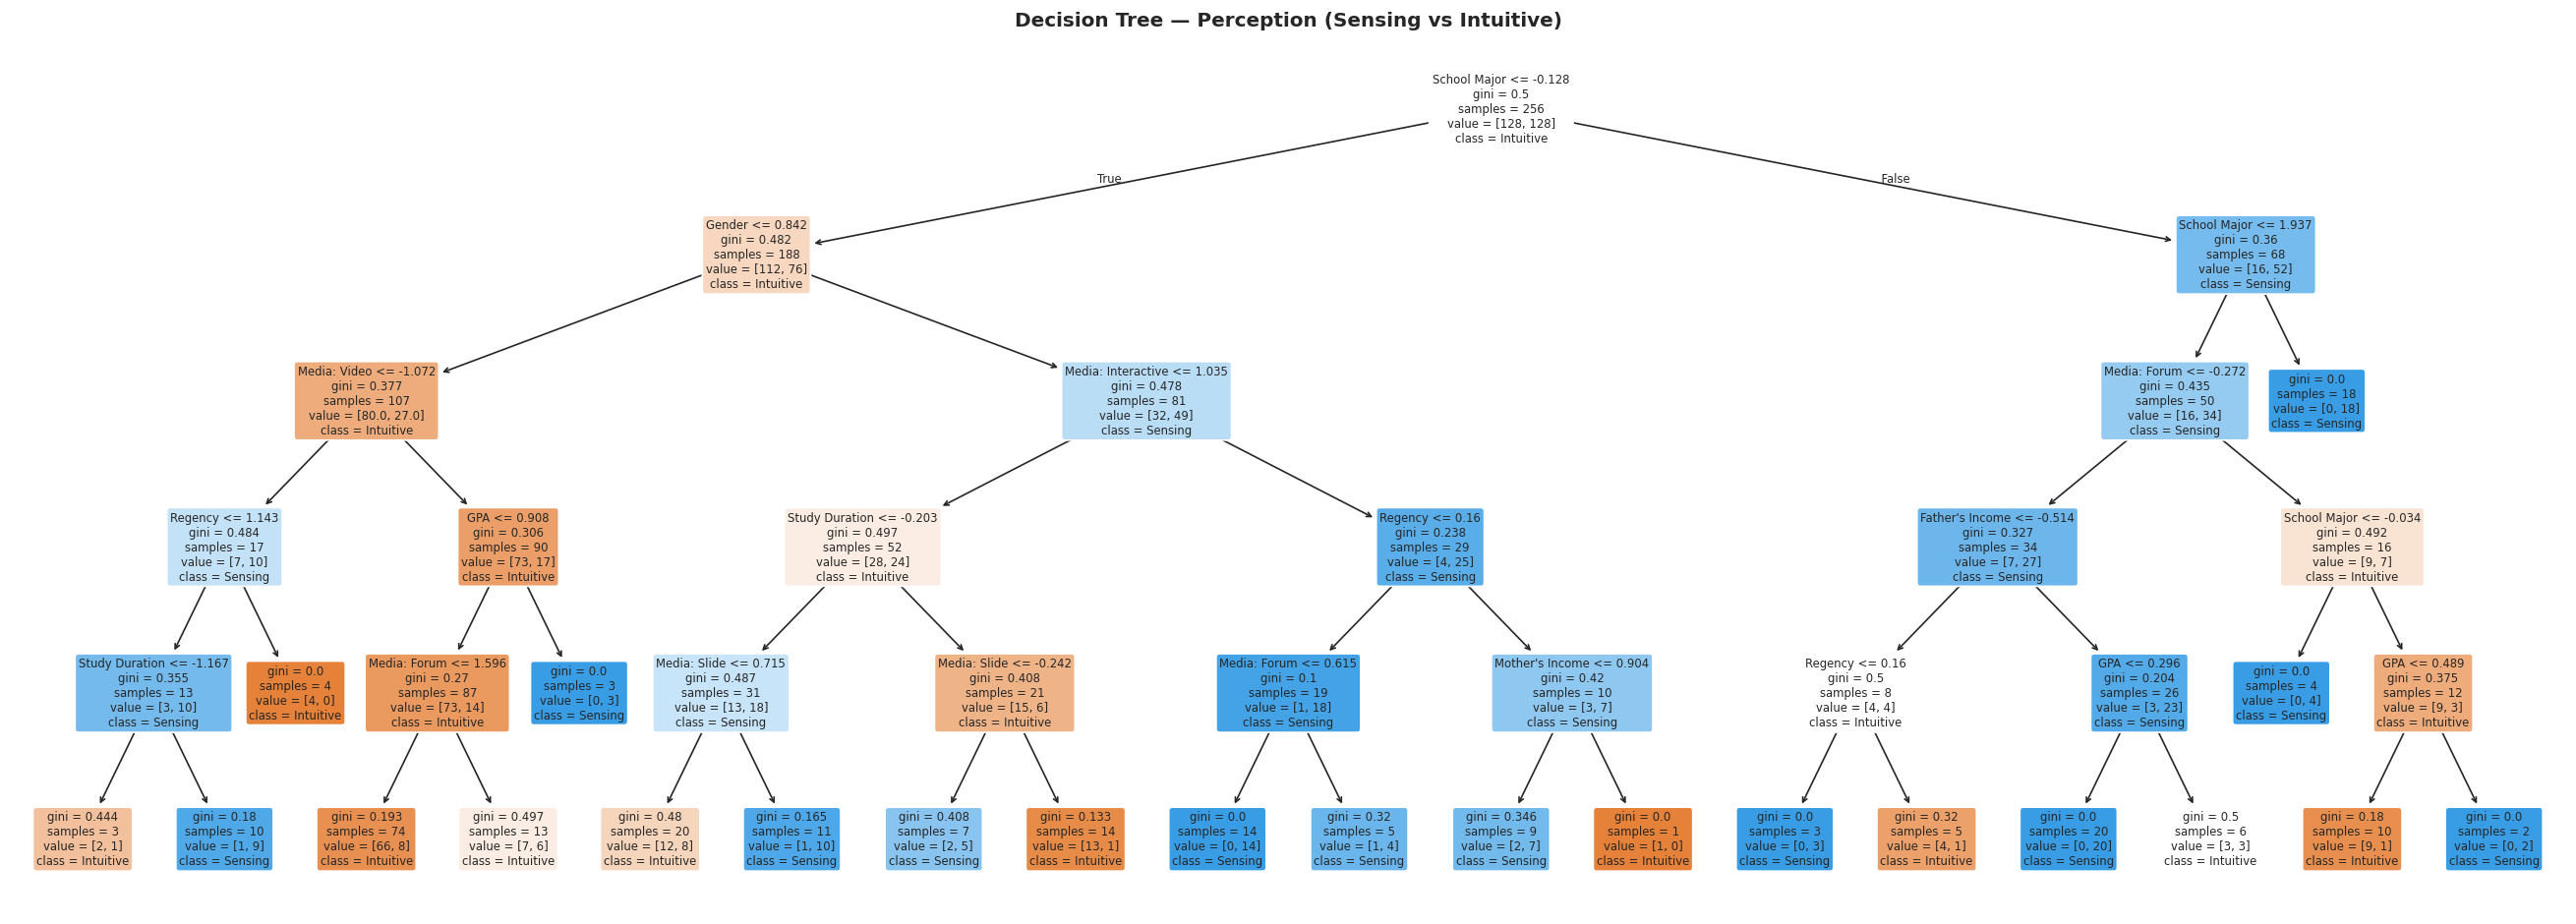


  Aturan Pohon (Decision Tree):
|--- Jurusan Sekolah <= -0.13
|   |--- Jenis Kelamin <= 0.84
|   |   |--- Media: Video <= -1.07
|   |   |   |--- Kabupaten <= 1.14
|   |   |   |   |--- Durasi Belajar <= -1.17
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Durasi Belajar >  -1.17
|   |   |   |   |   |--- class: 1
|   |   |   |--- Kabupaten >  1.14
|   |   |   |   |--- class: 0
|   |   |--- Media: Video >  -1.07
|   |   |   |--- IPK <= 0.91
|   |   |   |   |--- Media: Forum <= 1.60
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Media: Forum >  1.60
|   |   |   |   |   |--- class: 0
|   |   |   |--- IPK >  0.91
|   |   |   |   |--- class: 1
|   |--- Jenis Kelamin >  0.84
|   |   |--- Media: Interaktif <= 1.04
|   |   |   |--- Durasi Belajar <= -0.20
|   |   |   |   |--- Media: Slide <= 0.71
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Media: Slide >  0.71
|   |   |   |   |   |--- class: 1
|   |   |   |--- Durasi Belajar >  -0.20
|   |   |   |   |--- Media: Slide 

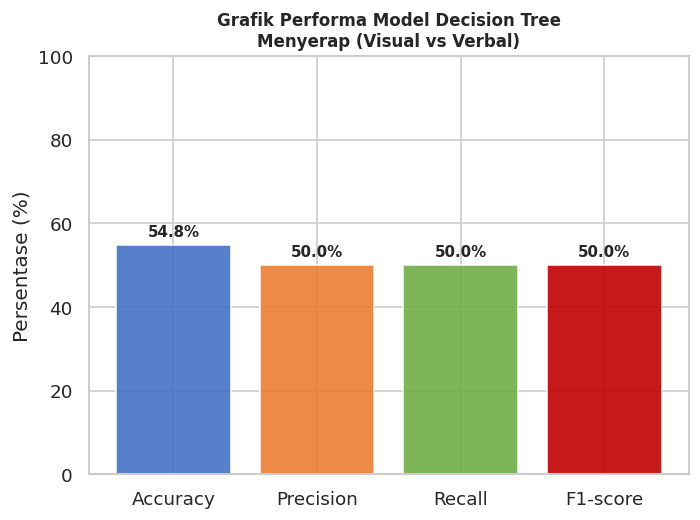

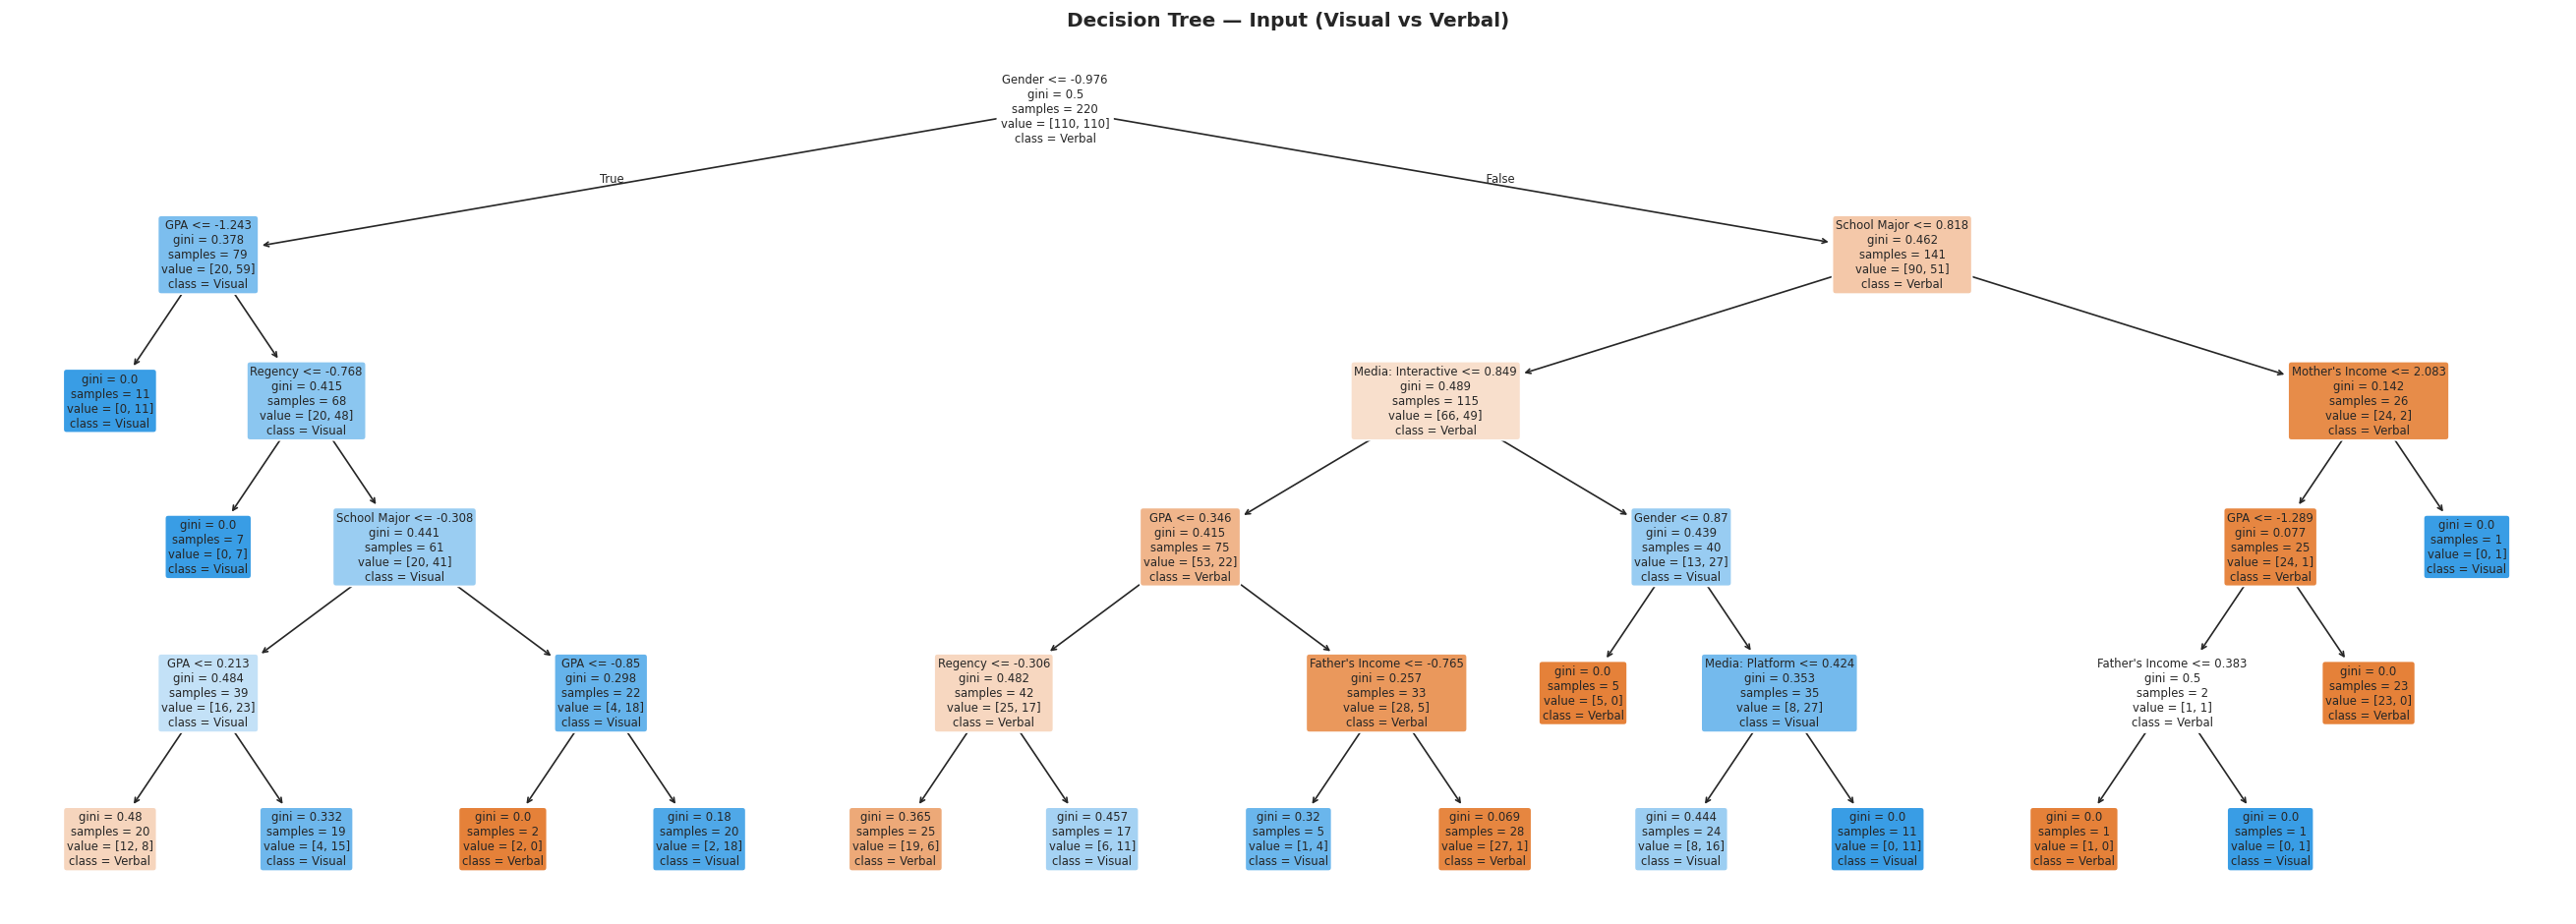


  Aturan Pohon (Decision Tree):
|--- Jenis Kelamin <= -0.98
|   |--- IPK <= -1.24
|   |   |--- class: 1
|   |--- IPK >  -1.24
|   |   |--- Kabupaten <= -0.77
|   |   |   |--- class: 1
|   |   |--- Kabupaten >  -0.77
|   |   |   |--- Jurusan Sekolah <= -0.31
|   |   |   |   |--- IPK <= 0.21
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- IPK >  0.21
|   |   |   |   |   |--- class: 1
|   |   |   |--- Jurusan Sekolah >  -0.31
|   |   |   |   |--- IPK <= -0.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- IPK >  -0.85
|   |   |   |   |   |--- class: 1
|--- Jenis Kelamin >  -0.98
|   |--- Jurusan Sekolah <= 0.82
|   |   |--- Media: Interaktif <= 0.85
|   |   |   |--- IPK <= 0.35
|   |   |   |   |--- Kabupaten <= -0.31
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Kabupaten >  -0.31
|   |   |   |   |   |--- class: 1
|   |   |   |--- IPK >  0.35
|   |   |   |   |--- Pendapatan Ayah <= -0.77
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Pendapatan Ayah >  -0.

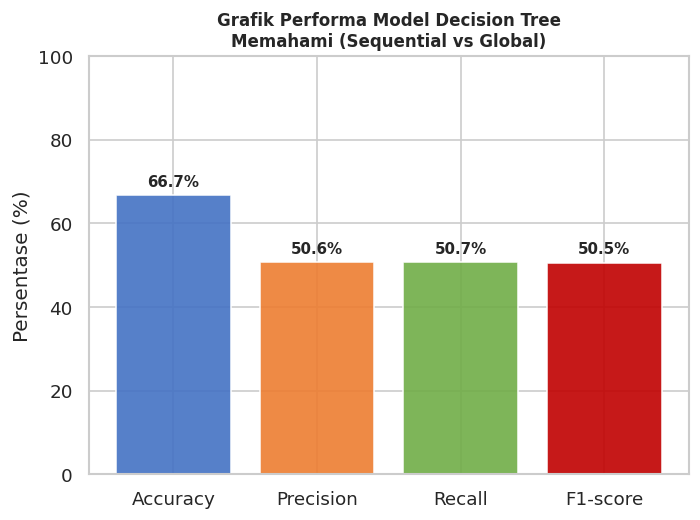

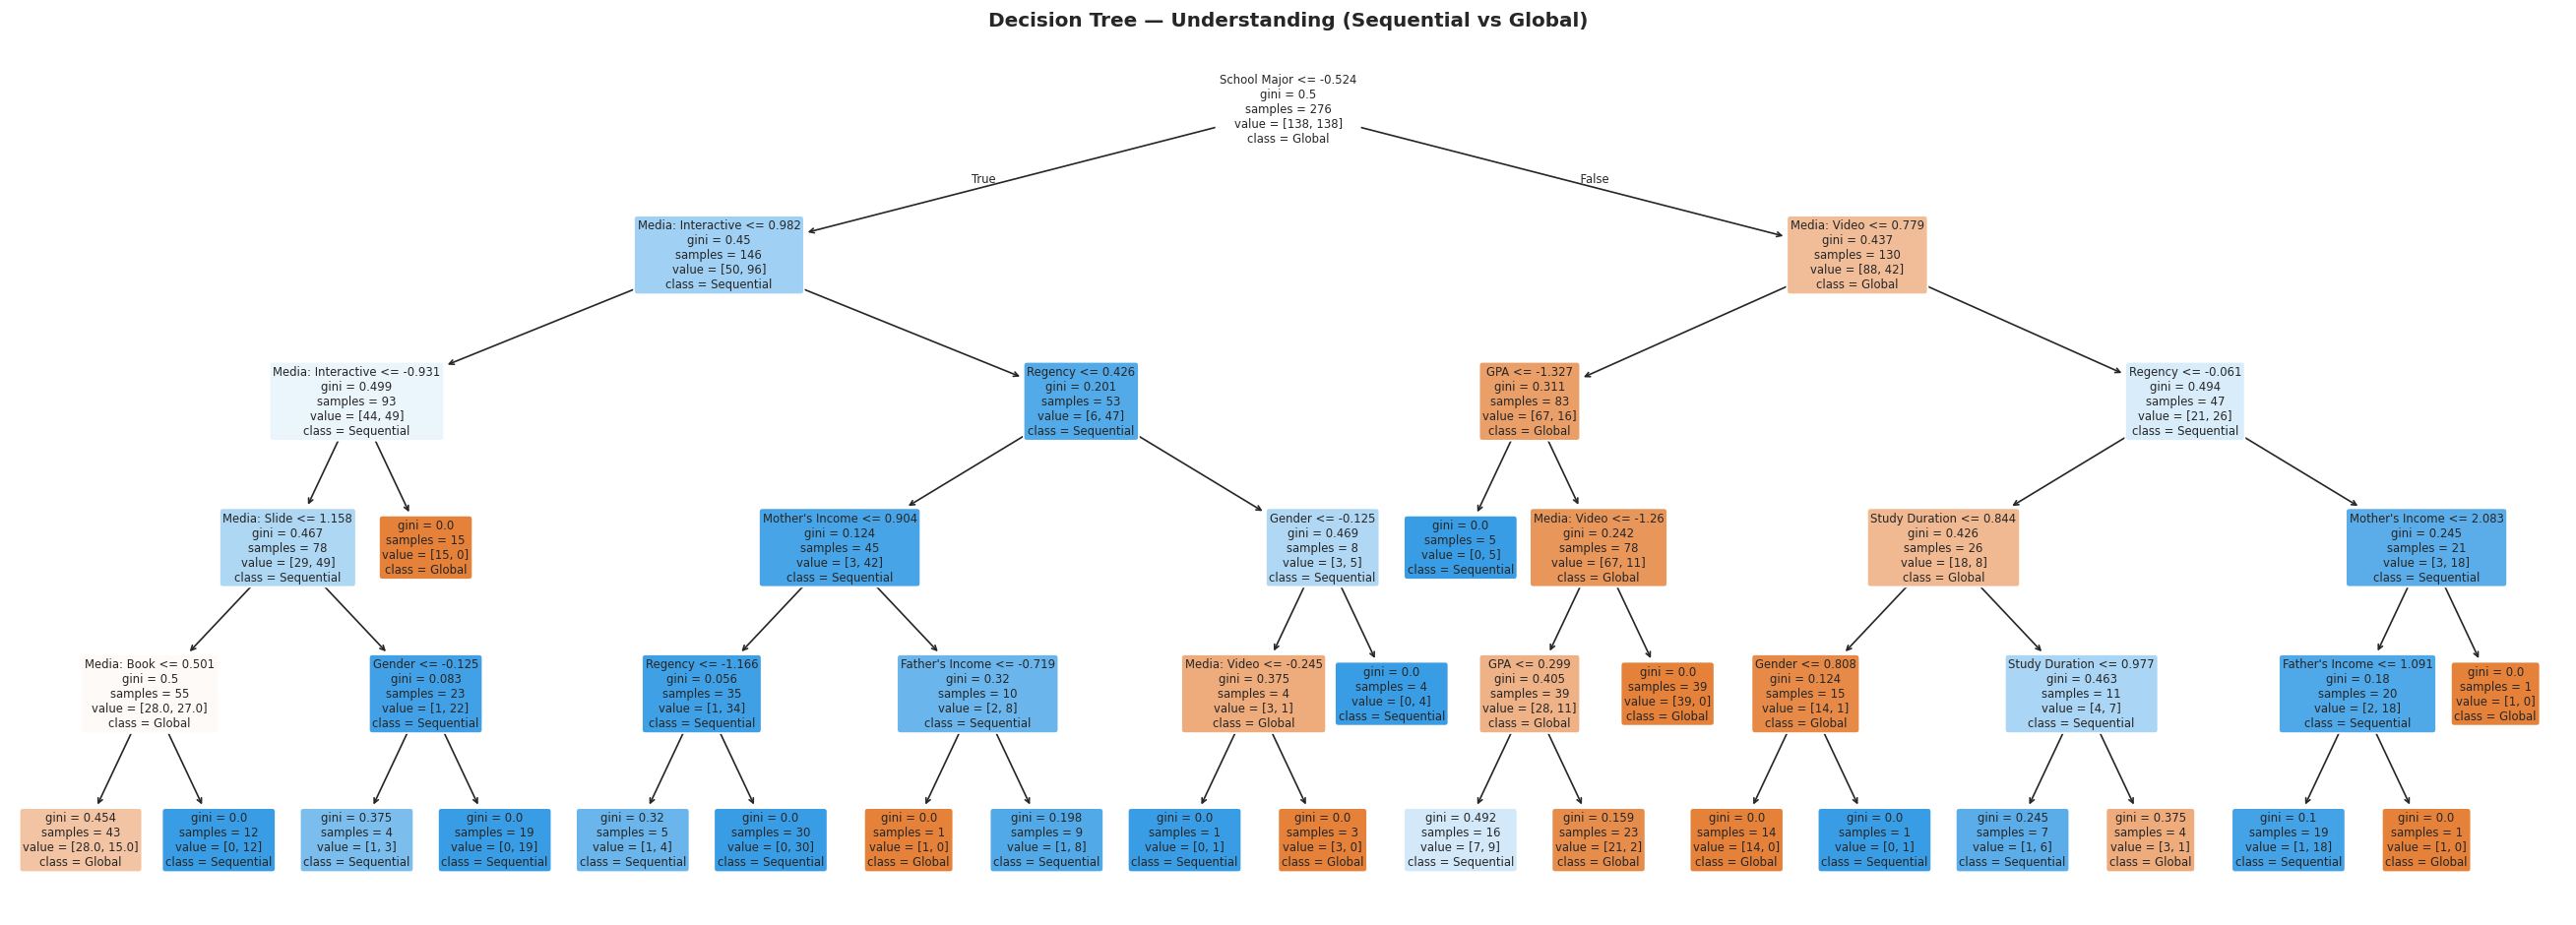


  Aturan Pohon (Decision Tree):
|--- Jurusan Sekolah <= -0.52
|   |--- Media: Interaktif <= 0.98
|   |   |--- Media: Interaktif <= -0.93
|   |   |   |--- Media: Slide <= 1.16
|   |   |   |   |--- Media: Buku <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Media: Buku >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Media: Slide >  1.16
|   |   |   |   |--- Jenis Kelamin <= -0.12
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Jenis Kelamin >  -0.12
|   |   |   |   |   |--- class: 1
|   |   |--- Media: Interaktif >  -0.93
|   |   |   |--- class: 0
|   |--- Media: Interaktif >  0.98
|   |   |--- Kabupaten <= 0.43
|   |   |   |--- Pendapatan Ibu <= 0.90
|   |   |   |   |--- Kabupaten <= -1.17
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Kabupaten >  -1.17
|   |   |   |   |   |--- class: 1
|   |   |   |--- Pendapatan Ibu >  0.90
|   |   |   |   |--- Pendapatan Ayah <= -0.72
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Pendapatan Ayah >  

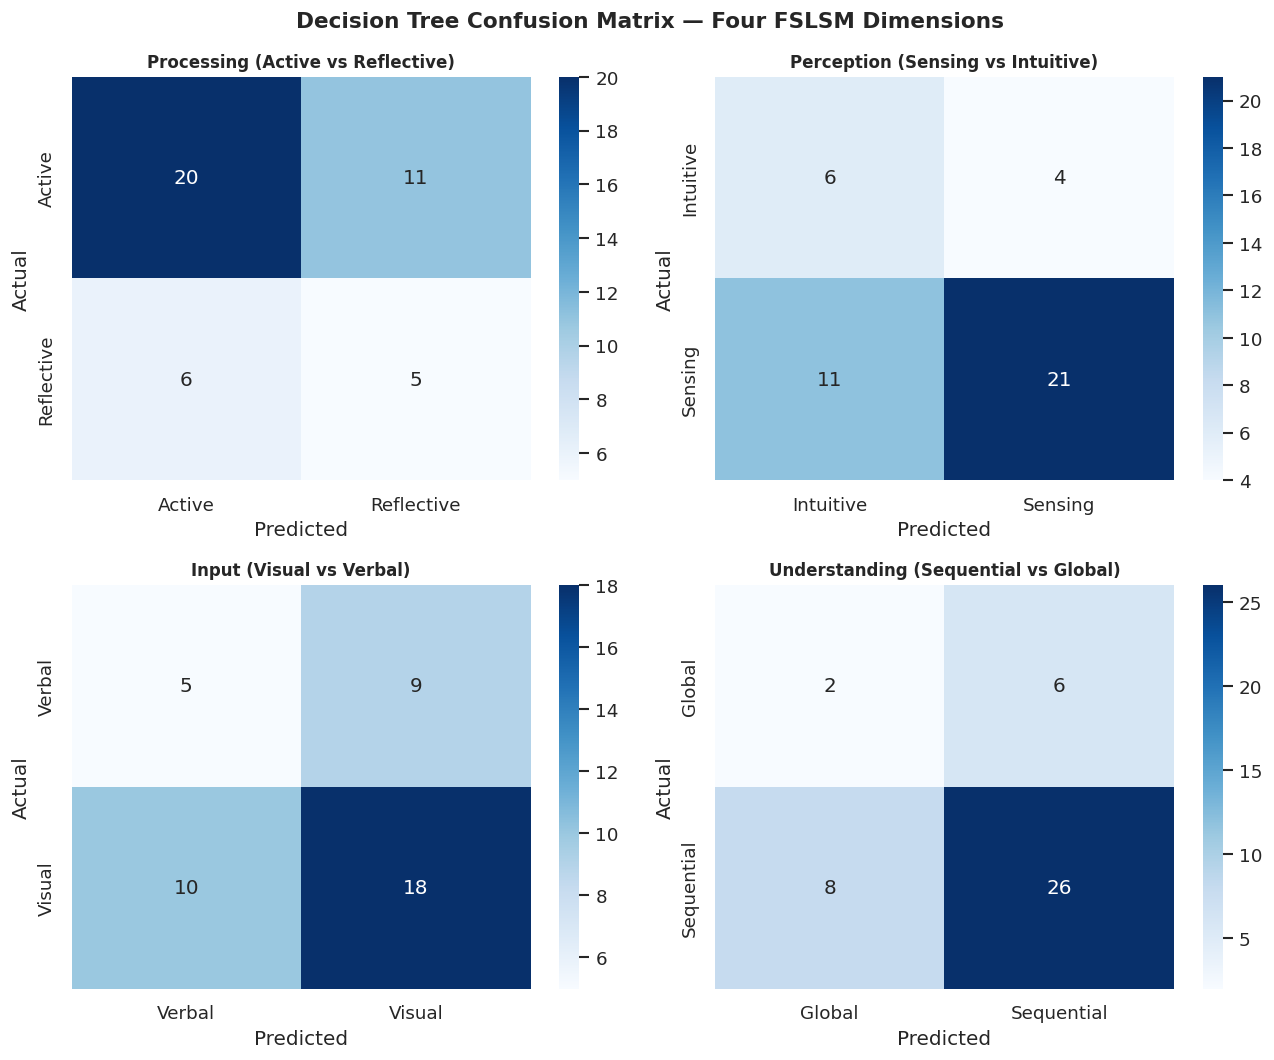


✅ Decision Tree selesai untuk semua dimensi.


In [ ]:
print("=" * 65)
print("  KLASIFIKASI — DECISION TREE (CART)")
print("  (criterion='gini', max_depth=5, class_weight='balanced')")
print("=" * 65)

cm_semua_dt = {}

for dimensi_nama, target_col in TARGET_COLS.items():
    print(f"\n▶ Dimensi: {dimensi_nama}")
    X_sm        = smote_dict[dimensi_nama]['X_train_sm']
    y_sm        = smote_dict[dimensi_nama]['y_train_sm']
    X_test      = split_dict[dimensi_nama]['X_test']
    y_test      = split_dict[dimensi_nama]['y_test']
    label_names = split_dict[dimensi_nama]['label_names']

    dt = DecisionTreeClassifier(criterion='gini', max_depth=5,
                                class_weight='balanced', random_state=42)
    dt.fit(X_sm, y_sm)
    y_pred = dt.predict(X_test)

    res = evaluasi(f"Decision Tree — {dimensi_nama}", y_test, y_pred, label_names)
    res['Dimensi'] = dimensi_nama
    all_results.append(res)

    trained_models[dimensi_nama].update({'dt': dt, 'y_pred_dt': y_pred})

    # Confusion Matrix (dikumpulkan; digambar gabungan setelah semua dimensi)
    cm_dt = confusion_matrix(y_test, y_pred)
    cm_semua_dt[dimensi_nama] = (cm_dt, label_names)

    # Rincian naratif confusion matrix + formula metrik eksplisit
    narasi_confusion_matrix(cm_dt, label_names, "Decision Tree", dimensi_nama)
    acc_f, prec_f, rec_f, f1_f = formula_metrik("Decision Tree", y_test, y_pred, label_names)

    # Contoh kesalahan prediksi pada data uji
    idx_test = split_dict[dimensi_nama]['idx_test']
    tampilkan_kesalahan_prediksi("Decision Tree", dimensi_nama, idx_test,
                                 y_test, y_pred, label_names, df)

    # Grafik performa (persentase) khusus dimensi ini
    plot_performa_persen("Decision Tree", dimensi_nama, acc_f, prec_f, rec_f, f1_f,
                          f'performa_dt_{target_col}.png')

    # Visualisasi Pohon (feature names in English)
    fig, ax = plt.subplots(figsize=(22, 8))
    plot_tree(dt, feature_names=feat_labels_en, class_names=label_names,
              filled=True, rounded=True, fontsize=7, ax=ax)
    ax.set_title(f"Decision Tree — {DIM_EN.get(dimensi_nama, dimensi_nama)}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'pohon_dt_{target_col}.png', bbox_inches='tight')
    plt.show()

    print(f"\n  Aturan Pohon (Decision Tree):")
    print(export_text(dt, feature_names=feat_labels))


# Confusion Matrix gabungan: satu gambar berisi empat dimensi FSLSM
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (dimensi_nama, (cm, label_names)) in zip(axes.flat, cm_semua_dt.items()):
    plot_cm(cm, label_names, dimensi_nama, ax)
fig.suptitle('Decision Tree Confusion Matrix — Four FSLSM Dimensions',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_dt_semua_dimensi.png', bbox_inches='tight')
plt.show()

print("\n✅ Decision Tree selesai untuk semua dimensi.")

  KLASIFIKASI — SVM
  (kernel='rbf', C=10, gamma='scale', class_weight='balanced')

▶ Dimensi: Memproses (Active vs Reflective)

  ───────────────────────────────────────────────────────
  SVM — Memproses (Active vs Reflective)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.5238  (52.38%)
  Precision : 0.6145
  Recall    : 0.5238
  F1-Score  : 0.5520

              precision    recall  f1-score   support

      Active       0.74      0.55      0.63        31
  Reflective       0.26      0.45      0.33        11

    accuracy                           0.52        42
   macro avg       0.50      0.50      0.48        42
weighted avg       0.61      0.52      0.55        42


  Rincian Confusion Matrix — SVM (Memproses (Active vs Reflective)):
  ────────────────────────────────────────────────────────────
  Kelas Active      : 17 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 14 data sebagai Reflective.
  Kelas Reflective  : 5 data berhasil 

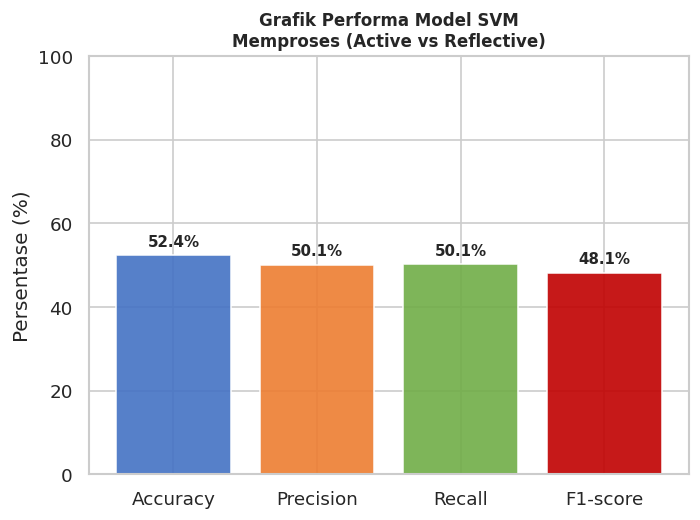


▶ Dimensi: Menerima (Sensing vs Intuitive)



  ───────────────────────────────────────────────────────
  SVM — Menerima (Sensing vs Intuitive)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.6429  (64.29%)
  Precision : 0.6775
  Recall    : 0.6429
  F1-Score  : 0.6574

              precision    recall  f1-score   support

   Intuitive       0.31      0.40      0.35        10
     Sensing       0.79      0.72      0.75        32

    accuracy                           0.64        42
   macro avg       0.55      0.56      0.55        42
weighted avg       0.68      0.64      0.66        42


  Rincian Confusion Matrix — SVM (Menerima (Sensing vs Intuitive)):
  ────────────────────────────────────────────────────────────
  Kelas Intuitive   : 4 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 6 data sebagai Sensing.
  Kelas Sensing     : 23 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 9 data sebagai Intuitive.
  Total data uji     : 42
  Prediksi benar     : 27 (6

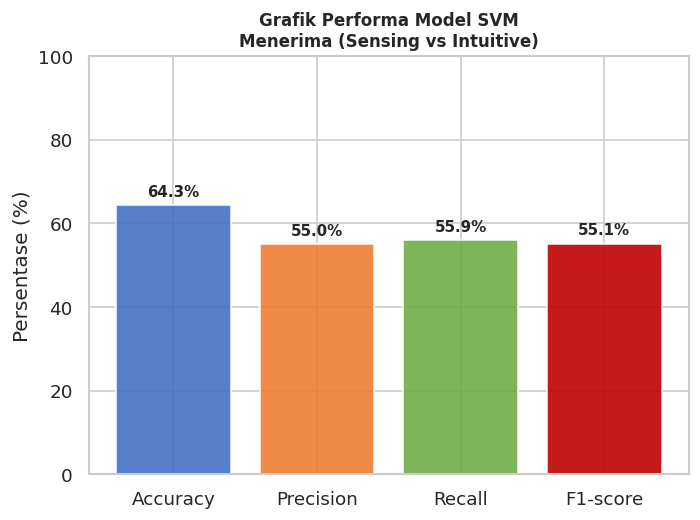


▶ Dimensi: Menyerap (Visual vs Verbal)

  ───────────────────────────────────────────────────────
  SVM — Menyerap (Visual vs Verbal)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.5238  (52.38%)
  Precision : 0.5238
  Recall    : 0.5238
  F1-Score  : 0.5238



              precision    recall  f1-score   support

      Verbal       0.29      0.29      0.29        14
      Visual       0.64      0.64      0.64        28

    accuracy                           0.52        42
   macro avg       0.46      0.46      0.46        42
weighted avg       0.52      0.52      0.52        42


  Rincian Confusion Matrix — SVM (Menyerap (Visual vs Verbal)):
  ────────────────────────────────────────────────────────────
  Kelas Verbal      : 4 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 10 data sebagai Visual.
  Kelas Visual      : 18 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 10 data sebagai Verbal.
  Total data uji     : 42
  Prediksi benar     : 22 (52.38%)
  Prediksi salah     : 20 (47.62%)

  Perhitungan Metrik Evaluasi — SVM:
  ────────────────────────────────────────────────────────────
  a. Accuracy
     Accuracy  = 22/42 = 0.5238
  b. Precision
     Precision = (0.2857 + 0.6429) / 2 = 0.4643
  c. 

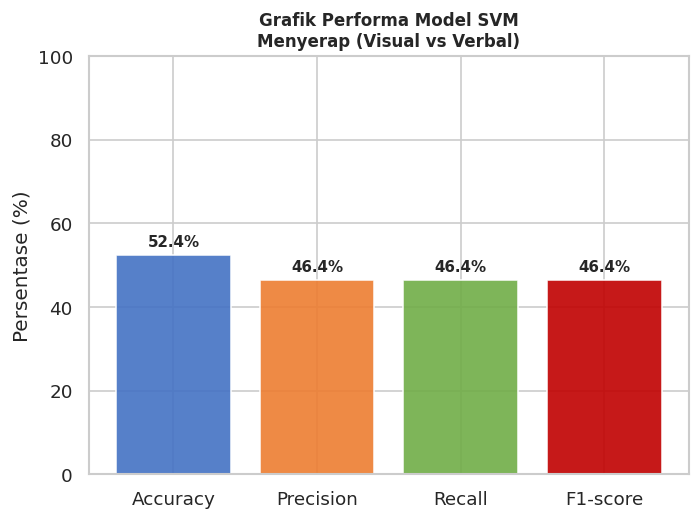


▶ Dimensi: Memahami (Sequential vs Global)

  ───────────────────────────────────────────────────────
  SVM — Memahami (Sequential vs Global)
  ───────────────────────────────────────────────────────
  Accuracy  : 0.7381  (73.81%)
  Precision : 0.6945
  Recall    : 0.7381
  F1-Score  : 0.7134



              precision    recall  f1-score   support

      Global       0.20      0.12      0.15         8
  Sequential       0.81      0.88      0.85        34

    accuracy                           0.74        42
   macro avg       0.51      0.50      0.50        42
weighted avg       0.69      0.74      0.71        42


  Rincian Confusion Matrix — SVM (Memahami (Sequential vs Global)):
  ────────────────────────────────────────────────────────────
  Kelas Global      : 1 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 7 data sebagai Sequential.
  Kelas Sequential  : 30 data berhasil diklasifikasikan dengan benar; kesalahan terjadi pada 4 data sebagai Global.
  Total data uji     : 42
  Prediksi benar     : 31 (73.81%)
  Prediksi salah     : 11 (26.19%)

  Perhitungan Metrik Evaluasi — SVM:
  ────────────────────────────────────────────────────────────
  a. Accuracy
     Accuracy  = 31/42 = 0.7381
  b. Precision
     Precision = (0.2000 + 0.8108) / 2 = 0.5054

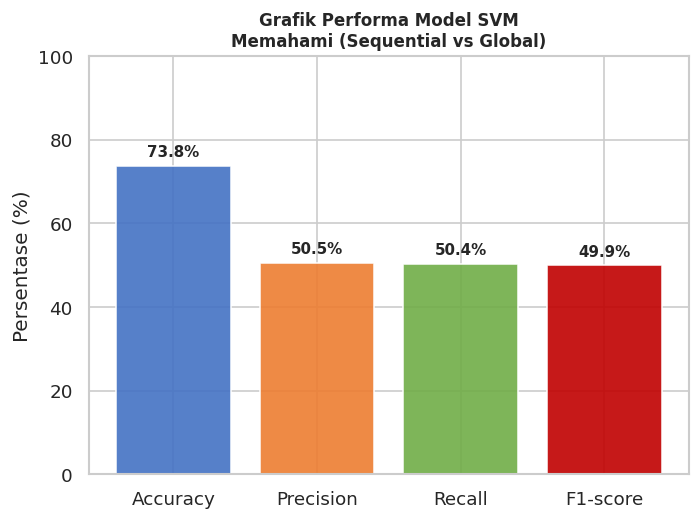

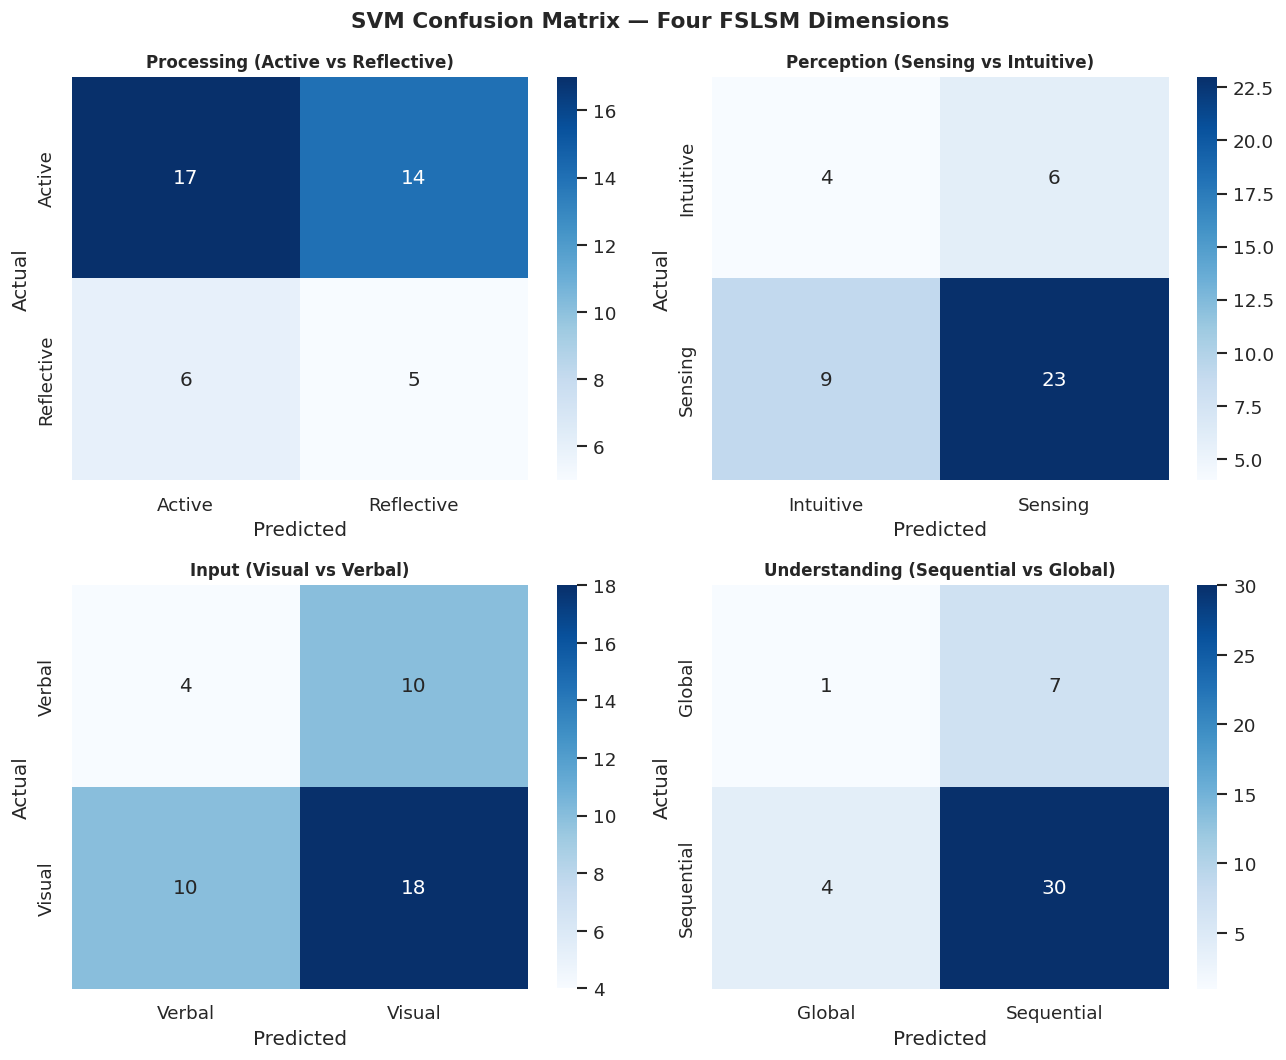


✅ SVM selesai untuk semua dimensi.


In [ ]:
print("=" * 65)
print("  KLASIFIKASI — SVM")
print("  (kernel='rbf', C=10, gamma='scale', class_weight='balanced')")
print("=" * 65)

cm_semua_svm = {}

for dimensi_nama, target_col in TARGET_COLS.items():
    print(f"\n▶ Dimensi: {dimensi_nama}")
    X_sm        = smote_dict[dimensi_nama]['X_train_sm']
    y_sm        = smote_dict[dimensi_nama]['y_train_sm']
    X_test      = split_dict[dimensi_nama]['X_test']
    y_test      = split_dict[dimensi_nama]['y_test']
    label_names = split_dict[dimensi_nama]['label_names']

    svm = SVC(kernel='rbf', C=10, gamma='scale',
              class_weight='balanced', random_state=42, probability=True)
    svm.fit(X_sm, y_sm)
    y_pred = svm.predict(X_test)

    res = evaluasi(f"SVM — {dimensi_nama}", y_test, y_pred, label_names)
    res['Dimensi'] = dimensi_nama
    all_results.append(res)

    trained_models[dimensi_nama].update({'svm': svm, 'y_pred_svm': y_pred})

    # Confusion Matrix (dikumpulkan; digambar gabungan setelah semua dimensi)
    cm_svm = confusion_matrix(y_test, y_pred)
    cm_semua_svm[dimensi_nama] = (cm_svm, label_names)

    # Rincian naratif confusion matrix + formula metrik eksplisit
    narasi_confusion_matrix(cm_svm, label_names, "SVM", dimensi_nama)
    acc_f, prec_f, rec_f, f1_f = formula_metrik("SVM", y_test, y_pred, label_names)

    # Contoh kesalahan prediksi pada data uji
    idx_test = split_dict[dimensi_nama]['idx_test']
    tampilkan_kesalahan_prediksi("SVM", dimensi_nama, idx_test,
                                 y_test, y_pred, label_names, df)

    # Grafik performa (persentase) khusus dimensi ini
    plot_performa_persen("SVM", dimensi_nama, acc_f, prec_f, rec_f, f1_f,
                          f'performa_svm_{target_col}.png')


# Confusion Matrix gabungan: satu gambar berisi empat dimensi FSLSM
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (dimensi_nama, (cm, label_names)) in zip(axes.flat, cm_semua_svm.items()):
    plot_cm(cm, label_names, dimensi_nama, ax)
fig.suptitle('SVM Confusion Matrix — Four FSLSM Dimensions',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_svm_semua_dimensi.png', bbox_inches='tight')
plt.show()

print("\n✅ SVM selesai untuk semua dimensi.")


  TABEL PERBANDINGAN KINERJA ALGORITMA
                         Dimensi         Model  Accuracy  Precision  Recall  F1-Score
Memproses (Active vs Reflective) Random Forest    0.6667     0.6465  0.6667    0.6552
 Menerima (Sensing vs Intuitive) Random Forest    0.7381     0.7292  0.7381    0.7332
     Menyerap (Visual vs Verbal) Random Forest    0.6429     0.6246  0.6429    0.6305
 Memahami (Sequential vs Global) Random Forest    0.7857     0.7544  0.7857    0.7655
Memproses (Active vs Reflective) Decision Tree    0.5952     0.6496  0.5952    0.6150
 Menerima (Sensing vs Intuitive) Decision Tree    0.6429     0.7240  0.6429    0.6672
     Menyerap (Visual vs Verbal) Decision Tree    0.5476     0.5556  0.5476    0.5513
 Memahami (Sequential vs Global) Decision Tree    0.6667     0.6958  0.6667    0.6801
Memproses (Active vs Reflective)           SVM    0.5238     0.6145  0.5238    0.5520
 Menerima (Sensing vs Intuitive)           SVM    0.6429     0.6775  0.6429    0.6574
     Menyerap 

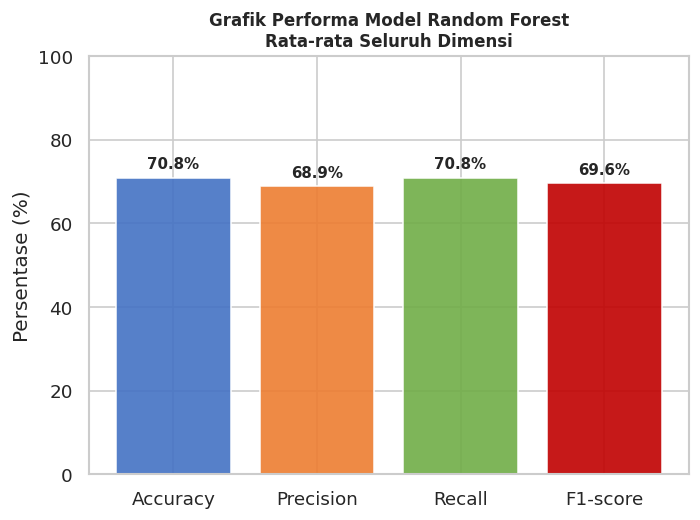

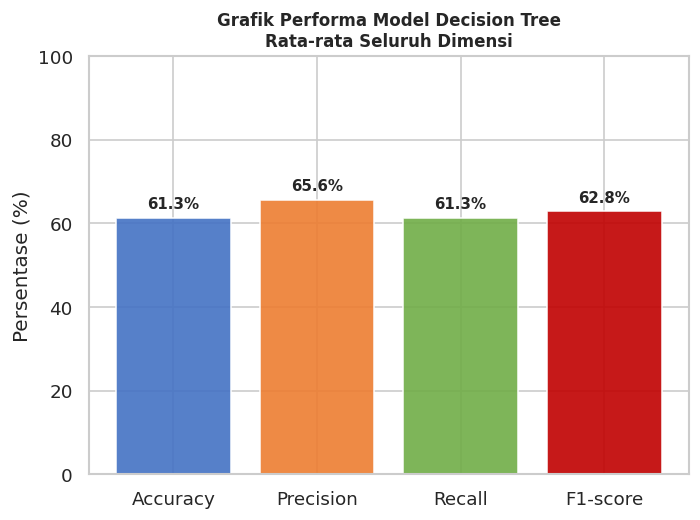

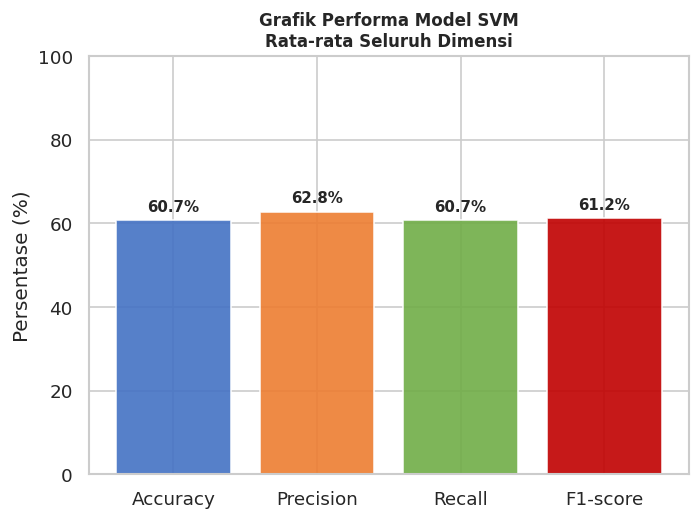

✅ Grafik performa keseluruhan tersimpan untuk RF, DT, dan SVM.


In [ ]:
"""**TABEL PERBANDINGAN KERJA & VISUALISASI**"""

model_list   = ['Random Forest', 'Decision Tree', 'SVM']
metrik_list  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_model = {'Random Forest':'#4CAF50', 'Decision Tree':'#FF9800', 'SVM':'#2196F3'}

df_results = pd.DataFrame(all_results)[
    ['Dimensi','Model','Accuracy','Precision','Recall','F1-Score']]
df_results['Model'] = df_results['Model'].apply(lambda x: x.split(' — ')[0])
df_results[metrik_list] = df_results[metrik_list].round(4)

print("\n" + "="*75)
print("  TABEL PERBANDINGAN KINERJA ALGORITMA")
print("="*75)
print(df_results.to_string(index=False))

avg_results = df_results.groupby('Model')[metrik_list].mean()
print("\nRata-rata kinerja per model (semua dimensi):")
print(avg_results.round(4).to_string())

# Grafik performa keseluruhan per model (rata-rata 4 dimensi), format persentase
# dengan label nilai di atas batang — setara "Grafik Performa Model" Bab IV.
print("\n" + "="*65)
print("  GRAFIK PERFORMA KESELURUHAN PER MODEL (RATA-RATA 4 DIMENSI)")
print("=" * 65)
for m in model_list:
    baris = avg_results.loc[m]
    plot_performa_persen(
        m, "Rata-rata Seluruh Dimensi",
        baris['Accuracy'], baris['Precision'], baris['Recall'], baris['F1-Score'],
        f"performa_keseluruhan_{m.lower().replace(' ', '_')}.png"
    )
print("✅ Grafik performa keseluruhan tersimpan untuk RF, DT, dan SVM.")

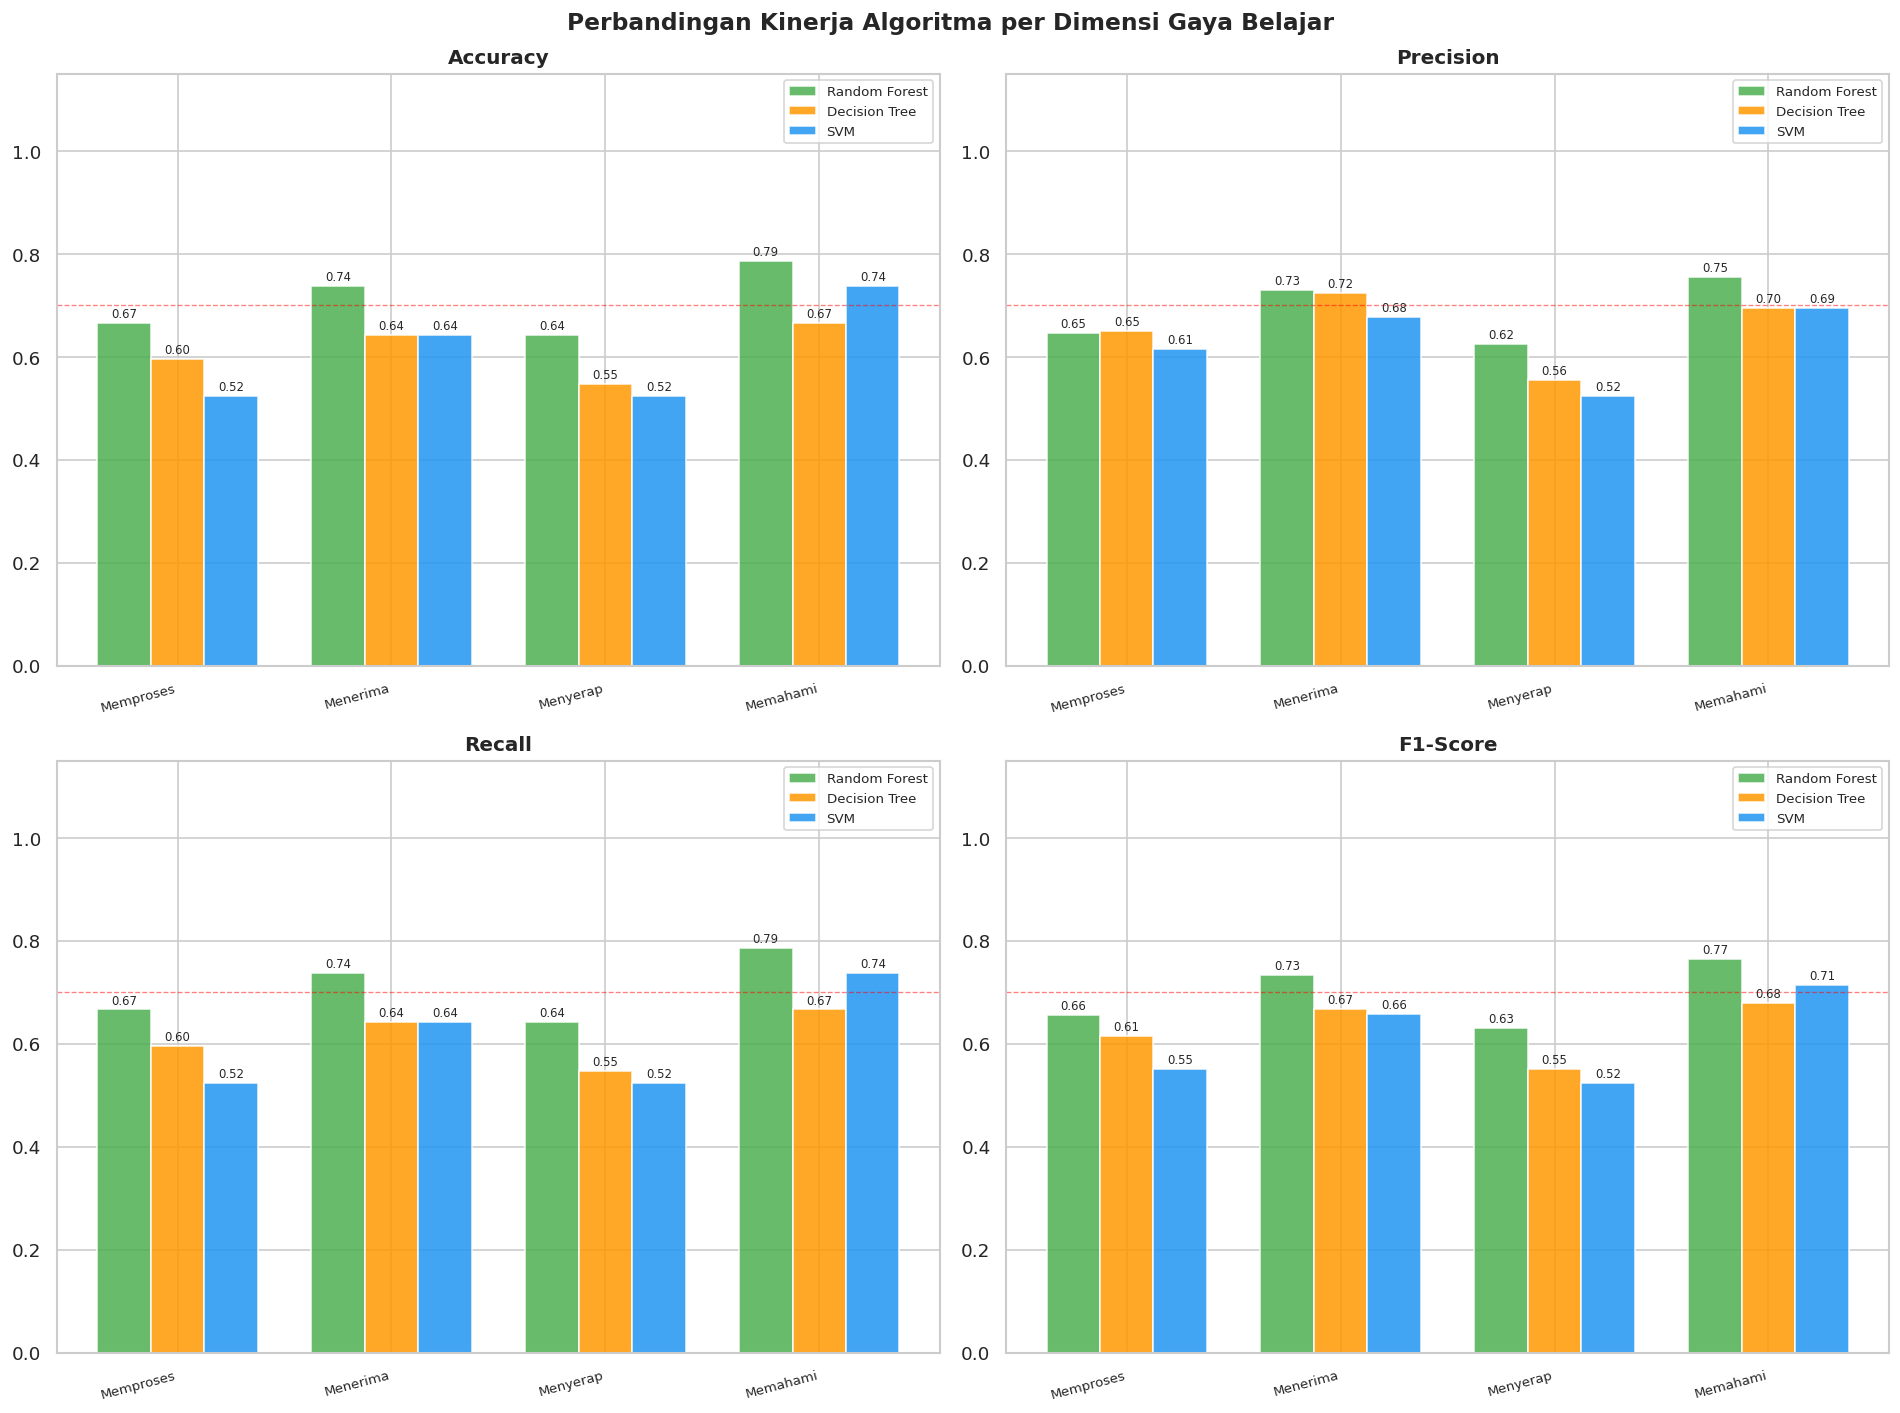

✅ Grafik perbandingan kinerja tersimpan.


In [ ]:
# Bar chart
dimensi_list = list(TARGET_COLS.keys())
fig, axes    = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Perbandingan Kinerja Algoritma per Dimensi Gaya Belajar",
             fontsize=14, fontweight='bold')
x = np.arange(len(dimensi_list))
w = 0.25
for ax, metrik in zip(axes.flatten(), metrik_list):
    for i, model in enumerate(model_list):
        vals = df_results[df_results['Model']==model][metrik].values
        bars = ax.bar(x+i*w, vals, w, label=model,
                      color=colors_model[model], alpha=0.85)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x+w)
    ax.set_xticklabels([d.split('(')[0].strip() for d in dimensi_list],
                       rotation=15, ha='right', fontsize=8)
    ax.set_title(metrik, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.axhline(0.7, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('perbandingan_kinerja.png', bbox_inches='tight')
plt.show()
print("✅ Grafik perbandingan kinerja tersimpan.")

In [ ]:
print("=" * 65)
print("  CROSS-VALIDATION 5-FOLD (RF, Decision Tree, SVM)")
print("=" * 65)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_records = []

for dimensi_nama in TARGET_COLS:
    X_sm = smote_dict[dimensi_nama]['X_train_sm']
    y_sm = smote_dict[dimensi_nama]['y_train_sm']
    for nama, model in [
        ('Random Forest', RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42)),
        ('Decision Tree', DecisionTreeClassifier(
            criterion='gini', max_depth=5,
            class_weight='balanced', random_state=42)),
        ('SVM', SVC(kernel='rbf', C=10, gamma='scale',
                    class_weight='balanced', random_state=42)),
    ]:
        scores = cross_val_score(model, X_sm, y_sm, cv=skf, scoring='accuracy')
        print(f"\n  [{dimensi_nama}] {nama}")
        print(f"  Akurasi tiap fold : {scores.round(4)}")
        print(f"  Mean ± Std        : {scores.mean():.4f} ± {scores.std():.4f}")
        cv_records.append({
            'Dimensi': dimensi_nama, 'Model': nama,
            'CV Mean Accuracy': round(scores.mean(), 4),
            'CV Std': round(scores.std(), 4),
        })

df_cv = pd.DataFrame(cv_records)
print(f"\nRingkasan Cross-Validation:")
print(df_cv.to_string(index=False))
print("\n✅ Cross-validation selesai.")

  CROSS-VALIDATION 5-FOLD (RF, Decision Tree, SVM)



  [Memproses (Active vs Reflective)] Random Forest
  Akurasi tiap fold : [0.8    0.9    0.9    0.7959 0.898 ]
  Mean ± Std        : 0.8588 ± 0.0497

  [Memproses (Active vs Reflective)] Decision Tree
  Akurasi tiap fold : [0.66   0.74   0.74   0.6735 0.6735]
  Mean ± Std        : 0.6974 ± 0.0351

  [Memproses (Active vs Reflective)] SVM
  Akurasi tiap fold : [0.8    0.88   0.78   0.898  0.9388]
  Mean ± Std        : 0.8593 ± 0.0601



  [Menerima (Sensing vs Intuitive)] Random Forest
  Akurasi tiap fold : [0.7115 0.8627 0.902  0.8039 0.8431]
  Mean ± Std        : 0.8247 ± 0.0648

  [Menerima (Sensing vs Intuitive)] Decision Tree
  Akurasi tiap fold : [0.5962 0.7059 0.7647 0.7647 0.7647]
  Mean ± Std        : 0.7192 ± 0.0656

  [Menerima (Sensing vs Intuitive)] SVM
  Akurasi tiap fold : [0.7885 0.8627 0.8824 0.9216 0.8627]
  Mean ± Std        : 0.8636 ± 0.0433



  [Menyerap (Visual vs Verbal)] Random Forest
  Akurasi tiap fold : [0.8636 0.7727 0.7273 0.7273 0.6818]
  Mean ± Std        : 0.7545 ± 0.0617

  [Menyerap (Visual vs Verbal)] Decision Tree
  Akurasi tiap fold : [0.75   0.8182 0.6591 0.6364 0.5455]
  Mean ± Std        : 0.6818 ± 0.0943

  [Menyerap (Visual vs Verbal)] SVM
  Akurasi tiap fold : [0.7955 0.7727 0.7045 0.8182 0.6818]
  Mean ± Std        : 0.7545 ± 0.0526



  [Memahami (Sequential vs Global)] Random Forest
  Akurasi tiap fold : [0.8929 0.9091 0.8909 0.9636 0.8364]
  Mean ± Std        : 0.8986 ± 0.0408

  [Memahami (Sequential vs Global)] Decision Tree
  Akurasi tiap fold : [0.6964 0.7818 0.7636 0.6364 0.7636]
  Mean ± Std        : 0.7284 ± 0.0545

  [Memahami (Sequential vs Global)] SVM
  Akurasi tiap fold : [0.8393 0.9273 0.8727 1.     0.9455]
  Mean ± Std        : 0.9169 ± 0.0562

Ringkasan Cross-Validation:
                         Dimensi         Model  CV Mean Accuracy  CV Std
Memproses (Active vs Reflective) Random Forest            0.8588  0.0497
Memproses (Active vs Reflective) Decision Tree            0.6974  0.0351
Memproses (Active vs Reflective)           SVM            0.8593  0.0601
 Menerima (Sensing vs Intuitive) Random Forest            0.8247  0.0648
 Menerima (Sensing vs Intuitive) Decision Tree            0.7192  0.0656
 Menerima (Sensing vs Intuitive)           SVM            0.8636  0.0433
     Menyerap (Visual vs V

  PREDIKSI DOMINAN GAYA BELAJAR PER KELOMPOK FITUR

─────────────────────────────────────────────────────────────────
  FITUR: Jenis Kelamin
─────────────────────────────────────────────────────────────────

  [Laki - Laki] (n=92)
  Dimensi                                   Aktual           RF           DT          SVM
  ─────────────────────────────────── ──────────── ──────────── ──────────── ────────────
  Memproses                            Active(76%)  Active(73%)  Active(61%)  Active(72%)
  Menerima                            Sensing(74%) Sensing(75%) Intuitive(50%) Sensing(73%)
  Menyerap                             Visual(78%)  Visual(82%)  Visual(75%)  Visual(76%)
  Memahami                            Sequential(78%) Sequential(80%) Sequential(70%) Sequential(82%)

  [Perempuan] (n=118)
  Dimensi                                   Aktual           RF           DT          SVM
  ─────────────────────────────────── ──────────── ──────────── ──────────── ────────────
  Memproses 

  Memahami                            Sequential(100%) Sequential(100%) Sequential(100%) Sequential(100%)

  [Lainnya] (n=86)
  Dimensi                                   Aktual           RF           DT          SVM
  ─────────────────────────────────── ──────────── ──────────── ──────────── ────────────
  Memproses                            Active(72%)  Active(74%)  Active(65%)  Active(70%)
  Menerima                            Sensing(74%) Sensing(76%) Sensing(62%) Sensing(74%)
  Menyerap                             Visual(62%)  Visual(65%)  Visual(53%)  Visual(63%)
  Memahami                            Sequential(80%) Sequential(80%) Sequential(74%) Sequential(81%)

  [Luwu] (n=4)
  Dimensi                                   Aktual           RF           DT          SVM
  ─────────────────────────────────── ──────────── ──────────── ──────────── ────────────
  Memproses                            Active(75%)  Active(75%) Active(100%)  Active(75%)
  Menerima                          


  [Pangkep] (n=9)
  Dimensi                                   Aktual           RF           DT          SVM
  ─────────────────────────────────── ──────────── ──────────── ──────────── ────────────
  Memproses                            Active(67%)  Active(67%)  Active(67%)  Active(67%)
  Menerima                            Sensing(67%) Sensing(67%) Sensing(56%) Sensing(67%)
  Menyerap                             Visual(67%)  Visual(78%)  Visual(78%)  Visual(56%)
  Memahami                            Sequential(78%) Sequential(78%) Sequential(67%) Sequential(78%)

  [Pinrang] (n=5)
  Dimensi                                   Aktual           RF           DT          SVM
  ─────────────────────────────────── ──────────── ──────────── ──────────── ────────────
  Memproses                           Active(100%)  Active(80%)  Active(80%) Active(100%)
  Menerima                            Sensing(60%) Sensing(80%) Sensing(60%) Sensing(80%)
  Menyerap                             Visual(60%)

,dimensi,kelas,jumlah_aktual,benar_rf,benar_dt,benar_svm
0,Memproses (Active vs Reflective),Active,155,149,120,141
1,Memproses (Active vs Reflective),Reflective,55,47,40,49
2,Menerima (Sensing vs Intuitive),Intuitive,50,44,41,44
3,Menerima (Sensing vs Intuitive),Sensing,160,155,120,151
4,Menyerap (Visual vs Verbal),Verbal,72,63,45,61
5,Menyerap (Visual vs Verbal),Visual,138,132,113,125
6,Memahami (Sequential vs Global),Global,38,32,25,31
7,Memahami (Sequential vs Global),Sequential,172,169,146,166


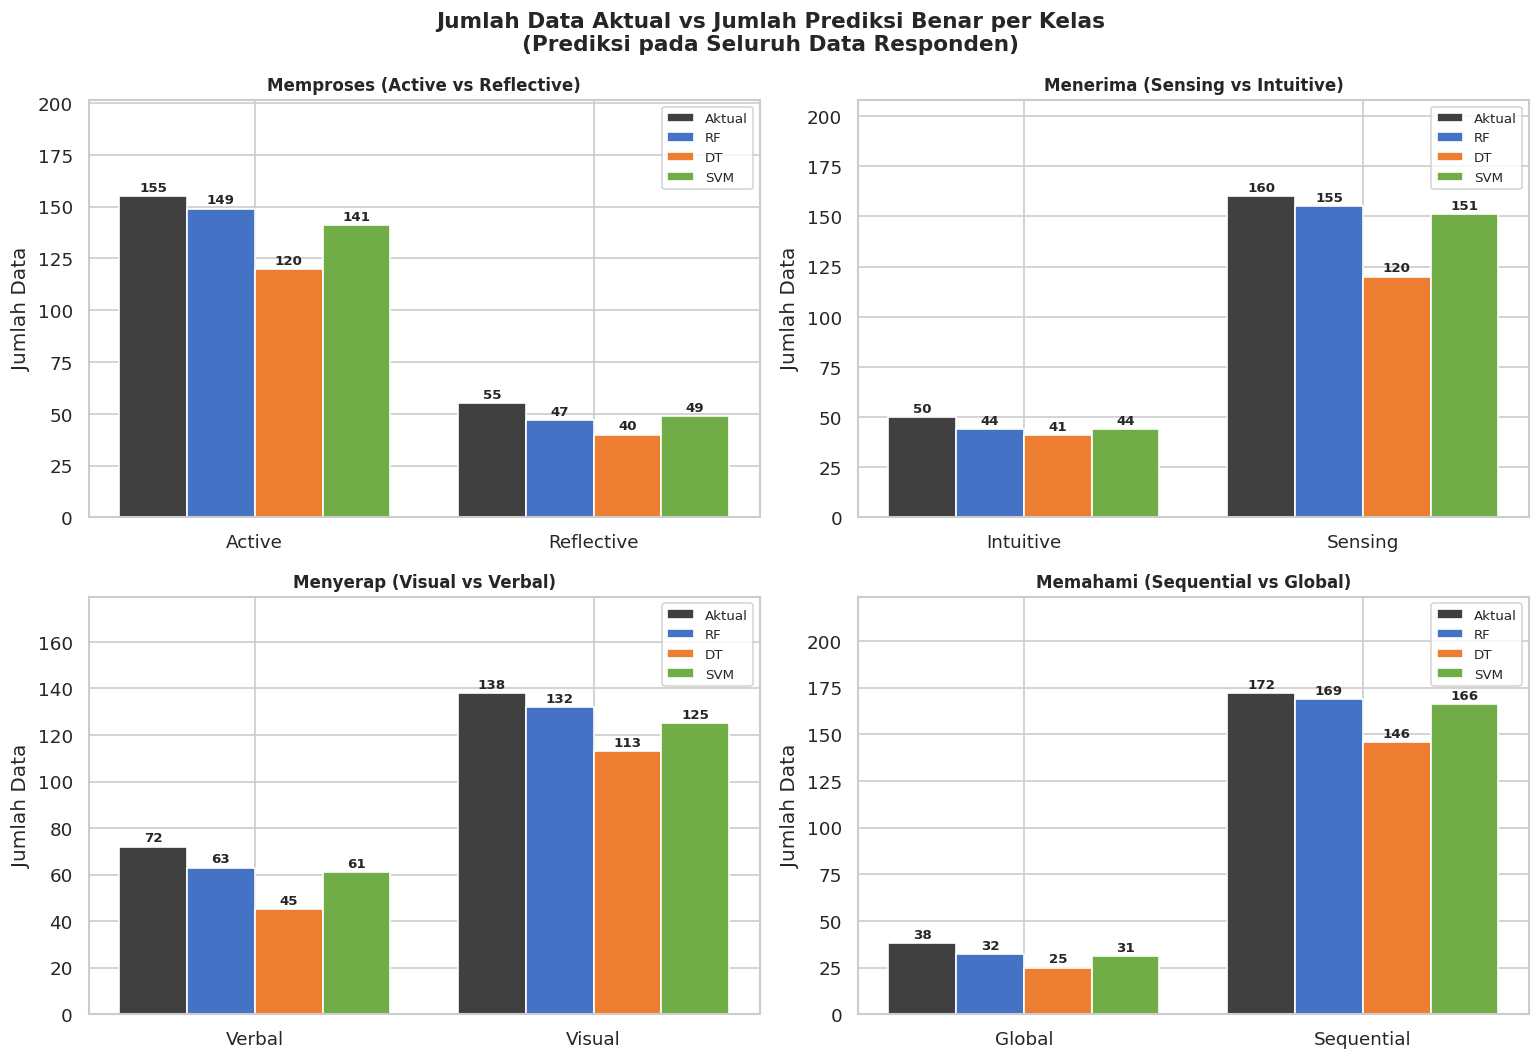


✅ Prediksi dominan selesai.


In [ ]:
print("=" * 65)
print("  PREDIKSI DOMINAN GAYA BELAJAR PER KELOMPOK FITUR")
print("=" * 65)

# Peta label untuk tiap fitur
peta_jk  = {v:k for k,v in zip(le_gender.classes_, le_gender.transform(le_gender.classes_))}
peta_jur = {v:k for k,v in zip(le_jurusan.classes_, le_jurusan.transform(le_jurusan.classes_))}
peta_kab = {v:k for k,v in zip(le_kabupaten.classes_, le_kabupaten.transform(le_kabupaten.classes_))}
peta_pend = {1:'<Rp2Jt', 2:'Rp2-5Jt', 3:'Rp5-8Jt', 4:'>Rp8Jt'}
peta_dur  = {1:'<30mnt', 2:'30mnt-1j', 3:'1-2j', 4:'>2j'}

# Fitur yang ditampilkan di prediksi dominan
# (hanya fitur yang punya label yang bisa dibaca — bukan kolom biner media)
FITUR_DOMINAN = [
    (0, 'Jenis Kelamin',   peta_jk),
    (1, 'Pendapatan Ayah', peta_pend),
    (2, 'Pendapatan Ibu',  peta_pend),
    (3, 'Kabupaten',       peta_kab),
    (4, 'Jurusan Sekolah', peta_jur),
    (6, 'Durasi Belajar',  peta_dur),
]

# Buat prediksi untuk semua 194 data
pred_all     = {}
dominan_rows = []

for dimensi_nama, target_col in TARGET_COLS.items():
    le_t = split_dict[dimensi_nama]['le_target']
    info = trained_models[dimensi_nama]
    pred_all[dimensi_nama] = {
        'aktual' : df[target_col].values,
        'RF'     : le_t.inverse_transform(info['rf'].predict(X_scaled)),
        'DT'     : le_t.inverse_transform(info['dt'].predict(X_scaled)),
        'SVM'    : le_t.inverse_transform(info['svm'].predict(X_scaled)),
    }

for col_idx, nama_f, peta in FITUR_DOMINAN:
    print(f"\n{'─'*65}")
    print(f"  FITUR: {nama_f}")
    print(f"{'─'*65}")

    for val_enc in sorted(set(X_raw[:, col_idx])):
        label_kel = peta.get(int(val_enc) if col_idx in [1,2,6] else int(val_enc), str(val_enc))
        mask = X_raw[:, col_idx] == val_enc
        n    = mask.sum()
        print(f"\n  [{label_kel}] (n={n})")
        print(f"  {'Dimensi':<35} {'Aktual':>12} {'RF':>12} {'DT':>12} {'SVM':>12}")
        print(f"  {'─'*35} {'─'*12} {'─'*12} {'─'*12} {'─'*12}")

        for dn in TARGET_COLS:
            preds     = pred_all[dn]
            akt_vc    = pd.Series(preds['aktual'][mask]).value_counts()
            rf_vc     = pd.Series(preds['RF'][mask]).value_counts()
            dt_vc     = pd.Series(preds['DT'][mask]).value_counts()
            svm_vc    = pd.Series(preds['SVM'][mask]).value_counts()
            top_a     = f"{akt_vc.index[0]}({akt_vc.iloc[0]/n*100:.0f}%)"
            top_rf    = f"{rf_vc.index[0]}({rf_vc.iloc[0]/n*100:.0f}%)"
            top_dt    = f"{dt_vc.index[0]}({dt_vc.iloc[0]/n*100:.0f}%)"
            top_svm   = f"{svm_vc.index[0]}({svm_vc.iloc[0]/n*100:.0f}%)"
            nama_dim  = dn.split('(')[0].strip()
            print(f"  {nama_dim:<35} {top_a:>12} {top_rf:>12} {top_dt:>12} {top_svm:>12}")

            for mn, label in [('RF','Random Forest'),('DT','Decision Tree'),('SVM','SVM')]:
                vc  = pd.Series(preds[mn][mask]).value_counts()
                dominan_rows.append({
                    'Fitur': nama_f, 'Kelompok': label_kel, 'N': n,
                    'Dimensi': dn, 'Sumber': label,
                    'Gaya Dominan': vc.index[0],
                    'Persentase (%)': round(vc.iloc[0]/n*100, 1),
                })

df_dominan = pd.DataFrame(dominan_rows)

# Tabel & grafik: jumlah data aktual vs jumlah yang berhasil diprediksi
# dengan benar per kelas (prediksi diterapkan pada seluruh data responden)
print("\nJumlah data aktual vs prediksi benar per kelas "
      f"(seluruh {len(df)} data):")
baris_benar = []
for dimensi_nama in TARGET_COLS:
    preds  = pred_all[dimensi_nama]
    aktual = preds['aktual']
    for kelas in split_dict[dimensi_nama]['label_names']:
        m = (aktual == kelas)
        baris_benar.append({
            'dimensi'      : dimensi_nama,
            'kelas'        : kelas,
            'jumlah_aktual': int(m.sum()),
            'benar_rf'     : int(((preds['RF']  == kelas) & m).sum()),
            'benar_dt'     : int(((preds['DT']  == kelas) & m).sum()),
            'benar_svm'    : int(((preds['SVM'] == kelas) & m).sum()),
        })
tabel_benar = pd.DataFrame(baris_benar)
display(tabel_benar)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
warna = {'Aktual': '#404040', 'RF': '#4472C4', 'DT': '#ED7D31', 'SVM': '#70AD47'}
for ax, dimensi_nama in zip(axes.flat, TARGET_COLS):
    sub   = tabel_benar[tabel_benar['dimensi'] == dimensi_nama]
    kelas = sub['kelas'].tolist()
    x     = np.arange(len(kelas)); lebar = 0.2
    seri  = [('Aktual', 'jumlah_aktual'), ('RF', 'benar_rf'),
             ('DT', 'benar_dt'), ('SVM', 'benar_svm')]
    for i, (nama, kol) in enumerate(seri):
        bars = ax.bar(x + (i - 1.5) * lebar, sub[kol].values, lebar,
                      label=nama, color=warna[nama])
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{int(bar.get_height())}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(kelas)
    ax.set_ylabel('Jumlah Data')
    ax.set_ylim(0, sub['jumlah_aktual'].max() * 1.3)
    ax.set_title(dimensi_nama, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Jumlah Data Aktual vs Jumlah Prediksi Benar per Kelas\n'
             '(Prediksi pada Seluruh Data Responden)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('prediksi_dominan_grafik.png', bbox_inches='tight')
plt.show()

print("\n✅ Prediksi dominan selesai.")

In [ ]:
print("\n" + "="*65)
print("  KESIMPULAN PENELITIAN")
print("="*65)

avg_acc  = df_results.groupby('Model')['Accuracy'].mean()
avg_f1   = df_results.groupby('Model')['F1-Score'].mean()
avg_prec = df_results.groupby('Model')['Precision'].mean()
avg_rec  = df_results.groupby('Model')['Recall'].mean()
best_acc = avg_acc.idxmax()

print(f"\n① RATA-RATA KINERJA PER MODEL (semua dimensi):")
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"  {'─'*60}")
for m in model_list:
    tag = " ← terbaik" if m == best_acc else ""
    print(f"  {m:<20} {avg_acc[m]:>10.4f} {avg_prec[m]:>10.4f} "
          f"{avg_rec[m]:>10.4f} {avg_f1[m]:>10.4f}{tag}")

print(f"\n② ALGORITMA TERBAIK PER DIMENSI:")
print(f"  {'Dimensi':<35} {'Model':<20} {'Accuracy':>10} {'F1':>8}")
print(f"  {'─'*75}")
for dn in TARGET_COLS:
    sub  = df_results[df_results['Dimensi']==dn]
    best = sub.loc[sub['Accuracy'].idxmax()]
    print(f"  {dn:<35} {best['Model']:<20} {best['Accuracy']:>10.4f} {best['F1-Score']:>8.4f}")

print(f"\n③ CATATAN METODOLOGI:")
print(f"   Dataset     : {len(df)} responden")
print(f"   Fitur       : {len(FEATURE_COLS)} (Jenis Kelamin, Pendapatan Ayah,")
print(f"                 Pendapatan Ibu, Kabupaten, Jurusan Sekolah,")
print(f"                 IPK, Durasi Belajar, 7 kolom Media Pembelajaran)")
print(f"   Split       : 80:20 stratified (sebelum SMOTE)")
print(f"   SMOTE       : Hanya data latih")
print(f"   Validasi    : Cross-validation 5-fold")
print(f"   Algoritma   : RF (200 pohon), DT (CART, max_depth=5), SVM (RBF, C=10)")
print("="*65)


  KESIMPULAN PENELITIAN

① RATA-RATA KINERJA PER MODEL (semua dimensi):
  Model                  Accuracy  Precision     Recall   F1-Score
  ────────────────────────────────────────────────────────────
  Random Forest            0.7084     0.6887     0.7084     0.6961 ← terbaik
  Decision Tree            0.6131     0.6562     0.6131     0.6284
  SVM                      0.6072     0.6276     0.6072     0.6117

② ALGORITMA TERBAIK PER DIMENSI:
  Dimensi                             Model                  Accuracy       F1
  ───────────────────────────────────────────────────────────────────────────
  Memproses (Active vs Reflective)    Random Forest            0.6667   0.6552
  Menerima (Sensing vs Intuitive)     Random Forest            0.7381   0.7332
  Menyerap (Visual vs Verbal)         Random Forest            0.6429   0.6305
  Memahami (Sequential vs Global)     Random Forest            0.7857   0.7655

③ CATATAN METODOLOGI:
   Dataset     : 210 responden
   Fitur       : 14 (Jeni